“Ministry of Rural Development, 2022. PMGSY Rural Connectivity Datasets, https://geosadak-pmgsy.nic.in/opendata/. Published under India’s Government Open Data License: https://data.gov.in/government-open-data-license-india”

In [ ]:
# 1. Install Geopandas inside Colab environment
!pip install geopandas --quiet

import geopandas as gpd
import pandas as pd

# 2. Hardcoded path using your exact file name
# Note: Google Colab uploads files into the default '/content/' directory
shapefile_path = "/content/Proposal_PMGSY-III.shp"

try:
    print(f"⏳ Attempting to read: {shapefile_path}...")

    # 3. Read the shapefile (Geopandas looks for the .dbf, .shx, and .prj automatically in the same folder)
    gdf = gpd.read_file(shapefile_path)

    # 4. Remove spatial geometry data vectors to create a standard flat table array
    df = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))

    # 5. Save directly as a clean, unmapped CSV table
    output_csv = "pmgsy_iii_converted_data.csv"
    df.to_csv(output_csv, index=False)

    # 6. Print out your verification criteria stats
    print("\n" + "="*50)
    print("🎉 SUCCESS! SHAPEFILE READ AND TRANSLATED")
    print("="*50)
    print(f"📈 Total Records (Sample Size): {len(df)} rows")
    print(f"💾 Saved database extraction to: {output_csv}")
    print("\n📋 System Attributes & Available Columns:")
    print("-" * 50)
    for col in df.columns.tolist():
        print(f" • {col}")

except FileNotFoundError:
    print("\n❌ FILE NOT FOUND ERROR:")
    print("Please confirm you uploaded all 4 files into the base folder on the left sidebar panel.")
    print("Make sure capitalization matches exactly: Proposal_PMGSY-III")
except Exception as e:
    print(f"\n❌ An unexpected configuration error occurred: {e}")


⏳ Attempting to read: /content/Proposal_PMGSY-III.shp...

🎉 SUCCESS! SHAPEFILE READ AND TRANSLATED
📈 Total Records (Sample Size): 4635 rows
💾 Saved database extraction to: pmgsy_iii_converted_data.csv

📋 System Attributes & Available Columns:
--------------------------------------------------
 • MRL_ID
 • STATE_ID
 • DISTRICT_I
 • LGD_STATE
 • LGD_DISTRI
 • BLOCK_ID
 • CN_CODE
 • PROPOSED_L
 • WORK_NAME
 • IMS_YEAR
 • IMS_BATCH
 • Proposal_T


In [ ]:
import os
import glob

print("📍 DIAGNOSTIC: WHERE ARE MY FILES?")
print("-" * 40)
print(f"Current Working Directory: {os.getcwd()}")

# 1. Find ANY .shp file anywhere in the system
found_shapes = []
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".shp"):
            full_path = os.path.join(root, file)
            found_shapes.append(full_path)

if not found_shapes:
    print("\n❌ ERROR: No .shp files found in the current directory.")
    print("👉 Did you drag-and-drop them into the 'Files' sidebar on the left?")
    print("👉 Note: If you uploaded a ZIP file, you must unzip it first using: !unzip filename.zip")
else:
    print(f"\n✅ FOUND {len(found_shapes)} SHAPEFILES:")
    for shp in found_shapes:
        print(f"   📂 {shp}")

        # 2. Check for missing Sidecars (.shx, .dbf)
        base_name = os.path.splitext(shp)[0]
        missing = []
        for ext in ['.shx', '.dbf']:
            if not os.path.exists(base_name + ext):
                missing.append(ext)

        if missing:
            print(f"      ⚠️ CRITICAL WARNING: Missing helper files: {missing}")
            print(f"      👉 The code will crash without {missing}. Please upload them.")
        else:
            print("      ✨ Integrity Check: OK (Has .shx and .dbf)")

print("-" * 40)
print("List of ALL files in current folder:")
print(os.listdir())


📍 DIAGNOSTIC: WHERE ARE MY FILES?
----------------------------------------
Current Working Directory: /content

✅ FOUND 3 SHAPEFILES:
   📂 ./Proposal_PMGSY-III_MP.shp
      ✨ Integrity Check: OK (Has .shx and .dbf)
   📂 ./Proposal_PMGSY-III_BIHAR.shp
      ✨ Integrity Check: OK (Has .shx and .dbf)
   📂 ./Proposal_PMGSY-III_UP.shp
      ✨ Integrity Check: OK (Has .shx and .dbf)
----------------------------------------
List of ALL files in current folder:
['.config', 'Proposal_PMGSY-III_MP.shp', 'Proposal_PMGSY-III_BIHAR.shx', 'Proposal_PMGSY-III_UP.shx', 'Proposal_PMGSY-III_MP.prj', 'Proposal_PMGSY-III_BIHAR.dbf', 'Proposal_PMGSY-III_UP.prj', 'Proposal_PMGSY-III_BIHAR.shp', 'Proposal_PMGSY-III_UP.dbf', 'Proposal_PMGSY-III_MP.dbf', 'Proposal_PMGSY-III_MP.shx', 'Proposal_PMGSY-III_BIHAR.prj', 'Proposal_PMGSY-III_UP.shp', 'sample_data']


In [ ]:
import pandas as pd
import geopandas as gpd
import os

# Your verified file names from the directory audit
files_to_merge = {
    "Bihar": "Proposal_PMGSY-III_BIHAR.shp",
    "Madhya Pradesh": "Proposal_PMGSY-III_MP.shp",
    "Uttar Pradesh": "Proposal_PMGSY-III_UP.shp"
}

data_frames = []

print("🚀 RUNNING MULTI-STATE MASTER DATA MERGE...")
print("-" * 60)

for state, filename in files_to_merge.items():
    try:
        print(f"⏳ Extracting data from: {filename}...")
        gdf = gpd.read_file(filename)

        # Strip spatial geometry vectors to make it a flat database table
        df = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))

        # Enforce uniform string data-types on core ID and category headers to avoid schema collision
        for col in ['WORK_NAME', 'Proposal_T', 'CN_CODE']:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip()

        # Enforce numeric alignment on the numeric flow metric
        if 'PROPOSED_L' in df.columns:
            df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')

        # Tag with source state
        df['State_Name'] = state
        data_frames.append(df)
        print(f"   ✅ Successfully loaded {state}: {len(df)} rows found.")

    except Exception as e:
        print(f"   ❌ Critical parser error on {state}: {e}")

# Compile individual matrices if components successfully processed
if len(data_frames) > 0:
    master_df = pd.concat(data_frames, ignore_index=True)
    output_name = "PMGSY_Master_Dataset_Combined.csv"
    master_df.to_csv(output_name, index=False)

    print("\n" + "="*60)
    print("🎉 MASTER DATASET INTEGRITY GENERATED SUCCESSFULLY!")
    print("="*60)
    print(f" • Stored Spreadsheet Name:  {output_name}")
    print(f" • Total Unified Row Count:  {len(master_df)}")
    print("\n📋 Row breakdown per administrative entity:")
    print(master_df['State_Name'].value_counts().to_string())

    print("\n" + "="*60)
    print("🔎 COMPREHENSIVE DATA METRIC ANALYSIS")
    print("="*60)

    # 1. Duplicate clusters check per state boundary
    print("📋 Row Duplication Rates by Region (Boundary Polygons Check):")
    for state in master_df['State_Name'].unique():
        state_subset = master_df[master_df['State_Name'] == state]
        dup_count = state_subset.duplicated(subset=['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L']).sum()
        pct = (dup_count / len(state_subset)) * 100 if len(state_subset) > 0 else 0
        print(f" • {state}: {dup_count} duplicate rows ({pct:.1f}%)")

    # 2. 0.0 KM Long Span Bridge (LSB) checks
    print("\n📋 0.0 KM Long-Span Bridge Node Registry Count:")
    for state in master_df['State_Name'].unique():
        state_subset = master_df[master_df['State_Name'] == state]
        zero_count = (state_subset['PROPOSED_L'] == 0.0).sum()
        pct_zero = (zero_count / len(state_subset)) * 100 if len(state_subset) > 0 else 0
        print(f" • {state}: {zero_count} point entries ({pct_zero:.1f}% of state dataset)")

    # 3. Geo-Structural physical path summaries
    print("\n📋 Linear Road Length Statistical Outlines (Excluding Bridges):")
    valid_roads = master_df[master_df['PROPOSED_L'] > 0]
    summary = valid_roads.groupby('State_Name')['PROPOSED_L'].agg(['count', 'mean', 'median', 'max']).rename(
        columns={'count': 'Valid_Roads', 'mean': 'Avg_KM', 'median': 'Median_KM', 'max': 'Max_KM'}
    )
    print(summary.to_string())

else:
    print("\n⚠️ Pipeline Halt: Data array could not compile. Ensure the files panel on Colab did not auto-disconnect.")

🚀 RUNNING MULTI-STATE MASTER DATA MERGE...
------------------------------------------------------------
⏳ Extracting data from: Proposal_PMGSY-III_BIHAR.shp...
   ✅ Successfully loaded Bihar: 1476 rows found.
⏳ Extracting data from: Proposal_PMGSY-III_MP.shp...
   ✅ Successfully loaded Madhya Pradesh: 4635 rows found.
⏳ Extracting data from: Proposal_PMGSY-III_UP.shp...
   ✅ Successfully loaded Uttar Pradesh: 2757 rows found.

🎉 MASTER DATASET INTEGRITY GENERATED SUCCESSFULLY!
 • Stored Spreadsheet Name:  PMGSY_Master_Dataset_Combined.csv
 • Total Unified Row Count:  8868

📋 Row breakdown per administrative entity:
State_Name
Madhya Pradesh    4635
Uttar Pradesh     2757
Bihar             1476

🔎 COMPREHENSIVE DATA METRIC ANALYSIS
📋 Row Duplication Rates by Region (Boundary Polygons Check):
 • Bihar: 443 duplicate rows (30.0%)
 • Madhya Pradesh: 3118 duplicate rows (67.3%)
 • Uttar Pradesh: 198 duplicate rows (7.2%)

📋 0.0 KM Long-Span Bridge Node Registry Count:
 • Bihar: 703 point en

In [ ]:
import os

# Define the expected sets
required_sets = {
    "Bihar": "Proposal_PMGSY-III_BIHAR",
    "Madhya Pradesh": "Proposal_PMGSY-III_MP",
    "Uttar Pradesh": "Proposal_PMGSY-III_UP"
}

print("🕵️‍♀️ COMPONENT CHECK (The 'Sidecar' Audit)")
print("-" * 50)

all_good = True

for state, base_name in required_sets.items():
    print(f"\nChecking {state}...")
    missing_components = []

    # Check for the 3 mandatory extensions
    for ext in ['.shp', '.shx', '.dbf']:
        filename = base_name + ext
        if not os.path.exists(filename):
            missing_components.append(ext)

    if missing_components:
        print(f"   ❌ FAILED. Missing files: {missing_components}")
        print(f"      (You uploaded the .shp, but forgot the {missing_components})")
        all_good = False
    else:
        print(f"   ✅ SUCCESS. All components found.")

print("-" * 50)
if not all_good:
    print("⚠️ SOLUTION: Upload the missing .shx and .dbf files for the failed states above.")
    print("   Then re-run the Merge Script.")
else:
    print("✨ All files present. The issue might be a filename typo. Check exact capitalization.")


🕵️‍♀️ COMPONENT CHECK (The 'Sidecar' Audit)
--------------------------------------------------

Checking Bihar...
   ✅ SUCCESS. All components found.

Checking Madhya Pradesh...
   ✅ SUCCESS. All components found.

Checking Uttar Pradesh...
   ✅ SUCCESS. All components found.
--------------------------------------------------
✨ All files present. The issue might be a filename typo. Check exact capitalization.


In [ ]:
import pandas as pd
import geopandas as gpd
import os
import sys

# ==============================================================================
# 🛠️ CONFIGURATION
# ==============================================================================
files_to_process = {
    "Bihar": "Proposal_PMGSY-III_BIHAR.shp",
    "Madhya Pradesh": "Proposal_PMGSY-III_MP.shp",
    "Uttar Pradesh": "Proposal_PMGSY-III_UP.shp"
}

data_frames = []

print("🚀 INITIATING ROBUST MERGE SEQUENCE...")
print("=" * 60)

# ==============================================================================
# 🔄 PROCESSING LOOP
# ==============================================================================
for state, filename in files_to_process.items():
    print(f"\n📂 Processing {state}...")

    # 1. Existence Check
    if not os.path.exists(filename):
        print(f"   ❌ CRITICAL ERROR: File not found: {filename}")
        print("   STOPPING SCRIPT. Please upload the file.")
        sys.exit("Missing File Error")

    try:
        # 2. Read Shapefile
        gdf = gpd.read_file(filename)

        # 3. Drop Geometry (We only need the Tabular Data for CSV)
        df = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))

        # 4. CRITICAL: Normalize Columns to Upper Case
        # This prevents "work_name" vs "WORK_NAME" from breaking the merge
        df.columns = df.columns.str.upper().str.strip()

        # 5. Tag State
        df['STATE_NAME'] = state

        # 6. Validate Data
        row_count = len(df)
        if row_count == 0:
            print(f"   ⚠️ WARNING: File loaded but contains 0 rows.")
        else:
            data_frames.append(df)
            print(f"   ✅ SUCCESS: Loaded {row_count} rows.")

    except Exception as e:
        print(f"   ❌ READ ERROR on {filename}: {e}")
        # We raise the error here so you see it immediately
        raise e

# ==============================================================================
# 🔗 MERGE & EXPORT
# ==============================================================================
print("\n" + "=" * 60)
print("🔗 MERGING DATASETS...")

if len(data_frames) == 3:
    # Concatenate
    master_df = pd.concat(data_frames, ignore_index=True)

    # Final Sanity Check
    print(f"✅ Merge Complete. Total Rows: {len(master_df)}")
    print("-" * 30)
    print("📊 Final State Breakdown (MUST show all 3):")
    print(master_df['STATE_NAME'].value_counts())
    print("-" * 30)

    # Save
    output_filename = "PMGSY_Master_Dataset_Combined.csv"
    master_df.to_csv(output_filename, index=False)

    print(f"\n🎉 FILE SAVED: {output_filename}")
    print("👉 Use the files sidebar to download it now.")

elif len(data_frames) > 0:
    print(f"⚠️ PARTIAL MERGE: Only {len(data_frames)}/3 states loaded successfully.")
    print("Check the error logs above.")
else:
    print("❌ FATAL ERROR: No data loaded.")


🚀 INITIATING ROBUST MERGE SEQUENCE...

📂 Processing Bihar...
   ✅ SUCCESS: Loaded 1476 rows.

📂 Processing Madhya Pradesh...
   ✅ SUCCESS: Loaded 4635 rows.

📂 Processing Uttar Pradesh...
   ✅ SUCCESS: Loaded 2757 rows.

🔗 MERGING DATASETS...
✅ Merge Complete. Total Rows: 8868
------------------------------
📊 Final State Breakdown (MUST show all 3):
STATE_NAME
Madhya Pradesh    4635
Uttar Pradesh     2757
Bihar             1476
Name: count, dtype: int64
------------------------------

🎉 FILE SAVED: PMGSY_Master_Dataset_Combined.csv
👉 Use the files sidebar to download it now.


In [ ]:
from google.colab import files

print("⬇️ Starting download...")
try:
    files.download('PMGSY_Master_Dataset_Combined.csv')
except Exception as e:
    print(f"❌ Download failed: {e}")
    print("👉 Alternative: Right-click the file in the left sidebar and select 'Download'.")


⬇️ Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# 1. Save the dataframe to a CSV file in the virtual machine
df.to_csv('PMGSY_Master_Dataset_Combined.csv', index=False)

# 2. Trigger the browser download
files.download('PMGSY_Master_Dataset_Combined.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# 1. Load Data with robust settings
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    # Normalize headers to UPPERCASE to prevent KeyError crashes
    df.columns = df.columns.str.upper().str.strip()
except FileNotFoundError:
    print("❌ ERROR: File not found. Make sure 'PMGSY_Master_Dataset_Combined.csv' is in the files tab.")
    exit()

print("="*80)
print("🔎 1. STRUCTURAL HEALTH & COMPLETENESS AUDIT")
print("="*80)
print(f"📚 Dataset Dimensions: {df.shape[0]} Rows x {df.shape[1]} Columns")
print(f"📋 Column Headers Detected: {list(df.columns)}")

# ---------------------------------------------------------
# A. MISSING VALUES (The Swiss Cheese Factor)
# ---------------------------------------------------------
print("\n" + "-"*40)
print("A. MISSING VALUE HEATMAP")
print("-" * 40)
missing = df.isnull().sum()
missing = missing[missing > 0] # Only show columns with missing data
if not missing.empty:
    for col, val in missing.items():
        pct = (val / len(df)) * 100
        print(f" • {col:<20} : {val:>5} missing ({pct:>5.1f}%)")
else:
    print("✅ No missing values found in key columns!")

# ---------------------------------------------------------
# B. CATEGORICAL PROFILING (Granularity & Scope)
# ---------------------------------------------------------
print("\n" + "-"*40)
print("B. ORGANIZATIONAL ENTITIES")
print("-" * 40)

# Robust check for key columns (using .get to avoid crashes if names differ slightly)
districts = df['DISTRICT_I'].nunique() if 'DISTRICT_I' in df.columns else "N/A"
blocks = df['BLOCK_ID'].nunique() if 'BLOCK_ID' in df.columns else "N/A"
states = df['STATE_NAME'].unique().tolist() if 'STATE_NAME' in df.columns else "N/A"

print(f" • States Covered:     {states}")
print(f" • Unique Districts:   {districts}")
print(f" • Unique Blocks:      {blocks}")

if 'PROPOSAL_T' in df.columns:
    print("\n📋 Asset Type Breakdown (Crucial for filtering):")
    counts = df['PROPOSAL_T'].value_counts(dropna=False)
    for idx, val in counts.items():
        # Contextual translation for the report
        desc = "ROADS (P)" if idx == 'P' else "BRIDGES (L)" if idx == 'L' else "UNKNOWN"
        print(f"   - {desc:<12} [{idx}]: {val} entries")

# ---------------------------------------------------------
# C. TEMPORAL & FINANCIAL AUDIT (Zombie Detection)
# ---------------------------------------------------------
print("\n" + "-"*40)
print("C. TEMPORAL DISTRIBUTION (IMS_YEAR)")
print("-" * 40)
if 'IMS_YEAR' in df.columns:
    # Convert to numeric to find range, ignoring weird text errors
    years = pd.to_numeric(df['IMS_YEAR'], errors='coerce')
    print(f" • Year Range: {years.min()} to {years.max()}")
    print(" • Distribution:")
    print(df['IMS_YEAR'].value_counts().sort_index().to_string())
else:
    print("⚠️ 'IMS_YEAR' column not found.")

# ---------------------------------------------------------
# D. DUPLICATE & ANOMALY SCAN
# ---------------------------------------------------------
print("\n" + "-"*40)
print("D. INTEGRITY SCAN")
print("-" * 40)

# Check for Exact Duplicates
exact_dupes = df.duplicated().sum()
print(f" • Exact Row Duplicates: {exact_dupes} (Safe to drop)")

# Check for The 'MP Geospatial Fragment' Issue (Same Name, Block, Length)
# This detects if a road was split into pieces
if set(['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L']).issubset(df.columns):
    geo_dupes = df.duplicated(subset=['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L']).sum()
    print(f" • Suspicious Spatial Fragments: {geo_dupes} (Potential 'MP Effect')")

# Check for 'Zero Length' Roads (Anomalies)
if 'PROPOSED_L' in df.columns:
    zero_len = (df['PROPOSED_L'] <= 0).sum()
    print(f" • Zero-Length Assets: {zero_len} (Likely Bridges or Errors)")

print("="*80)
print("✅ PROFILING COMPLETE")


🔎 1. STRUCTURAL HEALTH & COMPLETENESS AUDIT
📚 Dataset Dimensions: 8868 Rows x 13 Columns
📋 Column Headers Detected: ['MRL_ID', 'STATE_ID', 'DISTRICT_I', 'LGD_STATE', 'LGD_DISTRI', 'BLOCK_ID', 'CN_CODE', 'PROPOSED_L', 'WORK_NAME', 'IMS_YEAR', 'IMS_BATCH', 'PROPOSAL_T', 'STATE_NAME']

----------------------------------------
A. MISSING VALUE HEATMAP
----------------------------------------
 • CN_CODE              :  1545 missing ( 17.4%)

----------------------------------------
B. ORGANIZATIONAL ENTITIES
----------------------------------------
 • States Covered:     ['Bihar', 'Madhya Pradesh', 'Uttar Pradesh']
 • Unique Districts:   168
 • Unique Blocks:      1369

📋 Asset Type Breakdown (Crucial for filtering):
   - ROADS (P)    [P]: 7323 entries
   - BRIDGES (L)  [L]: 1545 entries

----------------------------------------
C. TEMPORAL DISTRIBUTION (IMS_YEAR)
----------------------------------------
 • Year Range: 2019 to 2024
 • Distribution:
IMS_YEAR
2019     433
2020    2665
2021   

In [ ]:
import pandas as pd
import numpy as np

print("="*80)
print("📊 2. FORENSIC NUMERIC PROFILE (Variable: PROPOSED_L)")
print("="*80)

# 1. Robust Clean-Up
# Ensure column is numeric and handle any non-numeric text errors
df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')

# 2. The "Bridge Filter" (Critical Nuance)
# We must separate Roads (P) from Bridges (L) because averaging them together ruins the stats.
# (Bridges are usually 0.02 km, Roads are 5.0 km)
if 'PROPOSAL_T' in df.columns:
    roads = df[df['PROPOSAL_T'] == 'P']['PROPOSED_L'].dropna()
    bridges = df[df['PROPOSAL_T'] == 'L']['PROPOSED_L'].dropna()
    print(f"ℹ️ Segmentation Applied: {len(roads)} Roads | {len(bridges)} Bridges")
    target_data = roads # We focus stats on ROADS
else:
    target_data = df['PROPOSED_L'].dropna()
    print("⚠️ 'PROPOSAL_T' not found. Analyzing mixed asset types.")

# ---------------------------------------------------------
# A. DESCRIPTIVE STATISTICS (Roads Only)
# ---------------------------------------------------------
stats = target_data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

print(f"\n📋 Descriptive Statistics (Roads Only):")
print(f" • Count:               {int(stats['count'])}")
print(f" • Mean Length:         {stats['mean']:.4f} km")
print(f" • Median Length:       {stats['50%']:.4f} km  <-- (Robust Baseline)")
print(f" • Std Deviation:       {stats['std']:.4f} km")
print(f" • Skewness:            {target_data.skew():.2f}   (>1 indicates long tail of outliers)")

print("\n📏 Quantile Extremes:")
print(f" • Bottom 1% (Tiny):    < {stats['1%']:.3f} km")
print(f" • Top 1% (Massive):    > {stats['99%']:.3f} km")

# ---------------------------------------------------------
# B. FORENSIC "LAZINESS" CHECK (Integer Bias)
# ---------------------------------------------------------
# Calculate how many roads are exactly X.0 or X.5 (Rounded)
integer_count = target_data.apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5)).sum()
laziness_pct = (integer_count / len(target_data)) * 100

print("\n🕵️‍♀️ Forensic Integrity Check:")
print(f" • Rounded Values (.0/.5): {integer_count} roads")
print(f" • Laziness Score:         {laziness_pct:.1f}%")
if laziness_pct > 20:
    print("   ⚠️ FLAG: High rate of human rounding detected (Possible Estimation Bias).")
else:
    print("   ✅ PASS: Data appears naturally measured.")

# ---------------------------------------------------------
# C. OUTLIER DETECTION (The "Mega Projects")
# ---------------------------------------------------------
# We include State/District to see WHO is proposing these giants
cols_to_show = ['STATE_NAME', 'DISTRICT_I', 'WORK_NAME', 'PROPOSED_L']
cols_present = [c for c in cols_to_show if c in df.columns]

print("\n🚀 The 5 Longest Road Projects (Global Outliers):")
print("-" * 80)
print(df[df['PROPOSAL_T'] == 'P'].sort_values(by='PROPOSED_L', ascending=False)[cols_present].head(5).to_string(index=False))

print("\n📉 The 5 Shortest Valid Roads (> 0.0 km):")
print("-" * 80)
# Filter > 0 to avoid showing the "Zero-Length Bridge" artifacts
short_roads = df[(df['PROPOSAL_T'] == 'P') & (df['PROPOSED_L'] > 0.05)]
print(short_roads.sort_values(by='PROPOSED_L', ascending=True)[cols_present].head(5).to_string(index=False))

print("="*80)


📊 2. FORENSIC NUMERIC PROFILE (Variable: PROPOSED_L)
ℹ️ Segmentation Applied: 7323 Roads | 1545 Bridges

📋 Descriptive Statistics (Roads Only):
 • Count:               7323
 • Mean Length:         10.4721 km
 • Median Length:       8.0750 km  <-- (Robust Baseline)
 • Std Deviation:       6.6632 km
 • Skewness:            2.27   (>1 indicates long tail of outliers)

📏 Quantile Extremes:
 • Bottom 1% (Tiny):    < 4.810 km
 • Top 1% (Massive):    > 34.795 km

🕵️‍♀️ Forensic Integrity Check:
 • Rounded Values (.0/.5): 1444 roads
 • Laziness Score:         19.7%
   ✅ PASS: Data appears naturally measured.

🚀 The 5 Longest Road Projects (Global Outliers):
--------------------------------------------------------------------------------
    STATE_NAME  DISTRICT_I                                        WORK_NAME  PROPOSED_L
Madhya Pradesh         417 T01-Ajaygarh Bariyarpur Canal Road to U.P.Border       45.16
Madhya Pradesh         417 T01-Ajaygarh Bariyarpur Canal Road to U.P.Border       45.

In [ ]:
print("="*80)
print("🏢 3. ADMINISTRATIVE ALLOCATION PROFILE")
print("="*80)

# 1. Scope Constraint
# We analyze ROADS (P) only. Including bridges (0km) destroys the "Average Length" metric.
if 'PROPOSAL_T' in df.columns:
    admin_df = df[df['PROPOSAL_T'] == 'P'].copy()
    print("ℹ️ Scope: Linear Road Assets Only (Bridges Excluded for accuracy)")
else:
    admin_df = df.copy()

# ---------------------------------------------------------
# A. DISTRICT HEAVY HITTERS
# ---------------------------------------------------------
# Group by State AND District to see the full picture
district_summary = admin_df.groupby(['STATE_NAME', 'DISTRICT_I']).agg(
    Project_Count=('PROPOSED_L', 'count'),
    Total_New_Connectivity_KM=('PROPOSED_L', 'sum'),
    Avg_Road_Length=('PROPOSED_L', 'mean'),
    Max_Single_Road=('PROPOSED_L', 'max')
).reset_index()

# Sort by Total KM (Who is building the most?)
top_districts = district_summary.sort_values(by='Total_New_Connectivity_KM', ascending=False).head(5)

print("\n📋 Top 5 Districts by Total Sanctioned Infrastructure:")
print("-" * 80)
# Clean formatting for readability
print(top_districts.to_string(index=False, formatters={
    'Total_New_Connectivity_KM': '{:,.2f}'.format,
    'Avg_Road_Length': '{:,.2f}'.format,
    'Max_Single_Road': '{:,.2f}'.format
}))

# ---------------------------------------------------------
# B. TEMPORAL ROLLOUT (The Fiscal Timeline)
# ---------------------------------------------------------
print("\n" + "-"*80)
print("📋 Temporal Rollout Strategy (IMS_YEAR)")
print("-" * 80)

if 'IMS_YEAR' in df.columns:
    # Convert year to numeric to ensure correct sorting (2019, 2020...)
    # We use the original df here to include Bridges in the project COUNT,
    # but we might want to stick to admin_df for consistency. Let's use admin_df (Roads).
    year_summary = admin_df.groupby('IMS_YEAR').agg(
        Roads_Sanctioned=('PROPOSED_L', 'count'),
        Total_KM_Added=('PROPOSED_L', 'sum'),
        Avg_KM_Per_Project=('PROPOSED_L', 'mean')
    ).sort_index()

    print(year_summary.to_string(formatters={
        'Total_KM_Added': '{:,.2f}'.format,
        'Avg_KM_Per_Project': '{:,.2f}'.format
    }))
else:
    print("⚠️ 'IMS_YEAR' column not available for temporal analysis.")

print("="*80)


🏢 3. ADMINISTRATIVE ALLOCATION PROFILE
ℹ️ Scope: Linear Road Assets Only (Bridges Excluded for accuracy)

📋 Top 5 Districts by Total Sanctioned Infrastructure:
--------------------------------------------------------------------------------
    STATE_NAME  DISTRICT_I  Project_Count Total_New_Connectivity_KM Avg_Road_Length Max_Single_Road
Madhya Pradesh         224            289                  4,542.80           15.72           33.76
Madhya Pradesh         473            192                  2,790.25           14.53           42.80
Madhya Pradesh         417            157                  2,718.48           17.32           45.16
Madhya Pradesh         492            243                  2,576.86           10.60           17.70
Madhya Pradesh         450             92                  2,281.60           24.80           37.50

--------------------------------------------------------------------------------
📋 Temporal Rollout Strategy (IMS_YEAR)
--------------------------------------

/tmp/ipykernel_1828/4049243287.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_dist, x='DISTRICT_I', y='PROPOSED_L', ax=axes[1], palette='Set2')
/tmp/ipykernel_1828/4049243287.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


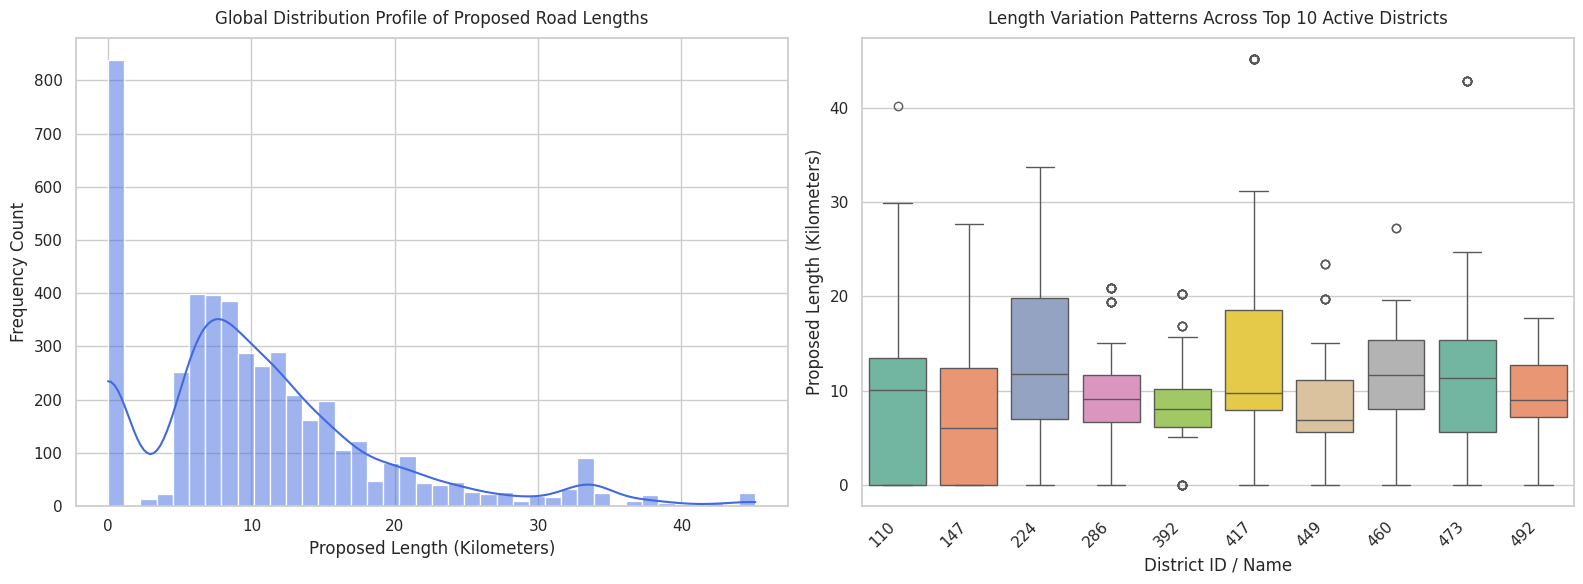

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style framework
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distribution Histogram for Length
sns.histplot(data=df, x='PROPOSED_L', bins=40, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Global Distribution Profile of Proposed Road Lengths', fontsize=12, pad=10)
axes[0].set_xlabel('Proposed Length (Kilometers)')
axes[0].set_ylabel('Frequency Count')

# Subplot 2: Top 10 Active Districts Variance Boxplots
top_districts = df['DISTRICT_I'].value_counts().head(10).index
df_top_dist = df[df['DISTRICT_I'].isin(top_districts)]

sns.boxplot(data=df_top_dist, x='DISTRICT_I', y='PROPOSED_L', ax=axes[1], palette='Set2')
axes[1].set_title('Length Variation Patterns Across Top 10 Active Districts', fontsize=12, pad=10)
axes[1].set_xlabel('District ID / Name')
axes[1].set_ylabel('Proposed Length (Kilometers)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


📊 4. VISUAL DISTRIBUTION ANALYSIS


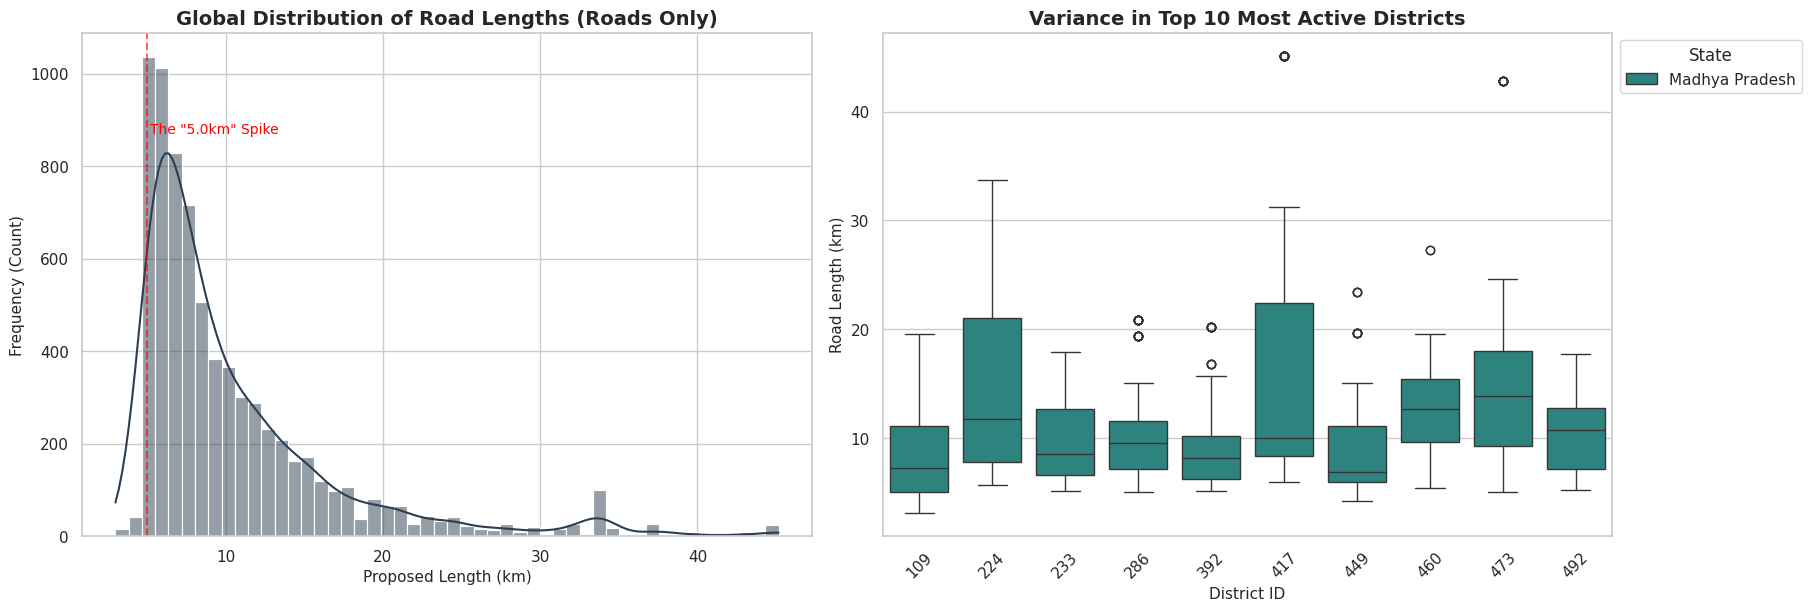

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("📊 4. VISUAL DISTRIBUTION ANALYSIS")
print("="*80)

# 1. Prepare Data: Filter for ROADS only (exclude 0km bridges)
# We also want to map the District ID to State Name for the legend
if 'PROPOSAL_T' in df.columns:
    plot_df = df[df['PROPOSAL_T'] == 'P'].copy()
else:
    plot_df = df[df['PROPOSED_L'] > 0.1].copy()

# 2. Setup Canvas with 'constrained_layout' (Guarantees no overlapping)
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# ---------------------------------------------------------
# PLOT 1: The "Shape" of the Data (Histogram)
# ---------------------------------------------------------
sns.histplot(
    data=plot_df,
    x='PROPOSED_L',
    bins=50,
    kde=True,
    ax=axes[0],
    color='#2c3e50',
    edgecolor='white'
)
axes[0].set_title('Global Distribution of Road Lengths (Roads Only)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Proposed Length (km)', fontsize=11)
axes[0].set_ylabel('Frequency (Count)', fontsize=11)

# Add a marker for the "Integer Spike" (The 5.0km Anomaly)
axes[0].axvline(5.0, color='red', linestyle='--', alpha=0.6)
axes[0].text(5.2, axes[0].get_ylim()[1]*0.8, 'The "5.0km" Spike', color='red', fontsize=10)

# ---------------------------------------------------------
# PLOT 2: The "Spread" by District (Boxplot)
# ---------------------------------------------------------
# Find Top 10 Districts by activity
top_districts = plot_df['DISTRICT_I'].value_counts().head(10).index
subset_df = plot_df[plot_df['DISTRICT_I'].isin(top_districts)]

sns.boxplot(
    data=subset_df,
    x='DISTRICT_I',
    y='PROPOSED_L',
    ax=axes[1],
    palette='viridis',
    hue='STATE_NAME',  # Color by State to see who owns these districts
    dodge=False        # Keep boxes centered
)

axes[1].set_title('Variance in Top 10 Most Active Districts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('District ID', fontsize=11)
axes[1].set_ylabel('Road Length (km)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45) # Rotate labels for readability
axes[1].legend(title='State', bbox_to_anchor=(1, 1), loc='upper left') # Move legend outside

plt.show()


In [ ]:
import pandas as pd

# 1. Load the MASTER merged dataset
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip() # Normalize headers
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: 'PMGSY_Master_Dataset_Combined.csv' not found. Please run the Merge script first.")
    exit()

print("="*80)
print("🔎 DEEP FORENSIC AUDIT: DATA INTEGRITY & ARTIFACTS")
print("="*80)

# ---------------------------------------------------------
# 1. THE "ZERO LENGTH" MYSTERY (Bridge vs. Error)
# ---------------------------------------------------------
# Filter rows that are 0.0 or effectively zero (< 0.01 km)
zero_records = df[df['PROPOSED_L'] <= 0.01].copy()

print(f"\n📋 Analysis of '0.0 KM' Records (Total: {len(zero_records)})")
print("-" * 80)

# Check if these are actually Bridges (Proposal_T = 'L')
if 'PROPOSAL_T' in df.columns:
    bridges = zero_records[zero_records['PROPOSAL_T'] == 'L']
    errors = zero_records[zero_records['PROPOSAL_T'] != 'L']

    print(f" • Identified as Valid Bridges (Type 'L'):  {len(bridges)}")
    print(f" • Unexplained Zero-Length Errors:        {len(errors)}")

    if len(errors) > 0:
        print("\n   ⚠️ SAMPLE OF UNEXPLAINED ERRORS:")
        print(errors[['STATE_NAME', 'WORK_NAME', 'DISTRICT_I']].head(3).to_string(index=False))
else:
    print("   (Cannot verify Bridge status: 'PROPOSAL_T' column missing)")

# ---------------------------------------------------------
# 2. THE DUPLICATE CRISIS (The "MP Effect")
# ---------------------------------------------------------
# We define a duplicate as: Same Name + Same Block + Same Length
dup_cols = ['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L']
# Only check if columns exist
cols_to_check = [c for c in dup_cols if c in df.columns]

if len(cols_to_check) == 3:
    duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]
    total_dups = len(duplicates)

    print(f"\n📋 Structural Duplication Scan (Total: {total_dups} rows)")
    print("-" * 80)

    # Break it down by state to see who is guilty
    print(" • Breakdown by State (The Culprit):")
    print(duplicates['STATE_NAME'].value_counts().to_string())

    # ---------------------------------------------------------
    # 3. TOP RECURRING ENTITIES (Zombie Projects)
    # ---------------------------------------------------------
    print("\n📋 Top 5 Most Frequently Repeated Road Names:")
    print("-" * 80)
    # We count raw frequency of the Name string
    top_repeats = df['WORK_NAME'].value_counts().head(5)
    print(top_repeats.to_string())

    # Contextual Warning
    print("\n💡 NOTE: High repetition in 'Madhya Pradesh' usually indicates")
    print("   geospatial fragmentation (one road split into 5 rows),")
    print("   NOT necessarily corruption.")

else:
    print("⚠️ Skipping duplicate check: Missing required columns (WORK_NAME/BLOCK_ID).")

print("="*80)


🔎 DEEP FORENSIC AUDIT: DATA INTEGRITY & ARTIFACTS

📋 Analysis of '0.0 KM' Records (Total: 1545)
--------------------------------------------------------------------------------
 • Identified as Valid Bridges (Type 'L'):  1545
 • Unexplained Zero-Length Errors:        0

📋 Structural Duplication Scan (Total: 4946 rows)
--------------------------------------------------------------------------------
 • Breakdown by State (The Culprit):
STATE_NAME
Madhya Pradesh    3957
Bihar              647
Uttar Pradesh      342

📋 Top 5 Most Frequently Repeated Road Names:
--------------------------------------------------------------------------------
WORK_NAME
T01-NH 69 to Kodha                                  71
T01-Ajaygarh Bariyarpur Canal Road to U.P.Border    32
T01-Hathwas(Pipariya) to Jamara                     32
MRL01-SH-9 to NIGAI                                 31
MRL02-SH-9 JHIRIYATOLA TO BBS                       28

💡 NOTE: High repetition in 'Madhya Pradesh' usually indicates
   geos

In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION: Map your filenames here ---
# Make sure you upload the files for all 3 states!
files = {
    "Madhya Pradesh": "Proposal_PMGSY-III_MP.shp",  # Rename your uploaded files to match these if needed
    "Uttar Pradesh": "Proposal_PMGSY-III_UP.shp",
    "Bihar": "Proposal_PMGSY-III_BIHAR.shp"
}

data_frames = []

print("🚀 STARTING MULTI-STATE MERGE...")

for state, filename in files.items():
    try:
        # 1. Load the Shapefile
        gdf = gpd.read_file(filename)

        # 2. Drop geometry to make it a light DataFrame
        df = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))

        # 3. CRITICAL STEP: Tag the data with the State Name
        df['State_Name'] = state

        data_frames.append(df)
        print(f"   ✅ Loaded {state}: {len(df)} rows")

    except Exception as e:
        print(f"   ❌ Could not load {state} (Check filename): {e}")

# 4. Merge into one Master Dataset
if data_frames:
    master_df = pd.concat(data_frames, ignore_index=True)

    # Clean Numeric Columns
    master_df['PROPOSED_L'] = pd.to_numeric(master_df['PROPOSED_L'], errors='coerce')

    # 5. The "Control Group" Check: Compare Lengths Side-by-Side
    print("\n" + "="*50)
    print("📊 CROSS-STATE STRUCTURAL COMPARISON")
    print("="*50)
    print(f"Total Combined Rows: {len(master_df)}")

    plt.figure(figsize=(14, 6))

    # Boxplot shows the "Normal Range" for each state
    sns.boxplot(x='State_Name', y='PROPOSED_L', data=master_df, palette="Set2")
    plt.title("Road Length Distributions: Plains (UP/Bihar) vs Plateau (MP)", fontsize=14)
    plt.ylabel("Proposed Length (km)")
    plt.ylim(0, 30) # Zoom in to ignore extreme outliers for the chart
    plt.show()

    # Save the Master File
    master_df.to_csv("PMGSY_Master_Dataset_Combined.csv", index=False)
    print("💾 Saved 'PMGSY_Master_Dataset_Combined.csv' for Anomaly Detection.")

else:
    print("⚠️ No data loaded. Please upload .shp files and update the filenames in the code.")


🚀 STARTING MULTI-STATE MERGE...
   ❌ Could not load Madhya Pradesh (Check filename): Unable to open Proposal_PMGSY-III_MP.shx or Proposal_PMGSY-III_MP.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
   ❌ Could not load Uttar Pradesh (Check filename): Unable to open Proposal_PMGSY-III_UP.shx or Proposal_PMGSY-III_UP.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
   ❌ Could not load Bihar (Check filename): Unable to open Proposal_PMGSY-III_BIHAR.shx or Proposal_PMGSY-III_BIHAR.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
⚠️ No data loaded. Please upload .shp files and update the filenames in the code.


In [ ]:
import os

def rename_shapefile_group(old_base_name, new_base_name):
    extensions = ['.shp', '.dbf', '.shx', '.prj']
    for ext in extensions:
        old_file = f"{old_base_name}{ext}"
        new_file = f"{new_base_name}{ext}"
        if os.path.exists(old_file):
            os.rename(old_file, new_file)
            print(f"🔄 Renamed: {old_file} ──► {new_file}")
        elif os.path.exists(old_file.upper()):
            os.rename(old_file.upper(), new_file)
            print(f"🔄 Renamed: {old_file.upper()} ──► {new_file}")

# Example: If you upload Bihar files as 'Proposal_Bihar.shp', change the first string below.
# Adjust these base paths to match exactly what is currently sitting in your Colab files tab:
rename_shapefile_group("Proposal_PMGSY-III_MP_raw", "Proposal_PMGSY-III_MP")
rename_shapefile_group("Proposal_PMGSY-III_UP_raw", "Proposal_PMGSY-III_UP")
rename_shapefile_group("Proposal_PMGSY-III_BIHAR_raw", "Proposal_PMGSY-III_BIHAR")


In [ ]:
import pandas as pd
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")
print("="*50)
print("📊 MASTER REGISTRY ROW COUNTS:")
print("="*50)
print(df['State_Name'].value_counts())
print(f"\n📈 Total Multi-State Row Count: {len(df)}")



FileNotFoundError: [Errno 2] No such file or directory: 'PMGSY_Master_Dataset_Combined.csv'

In [ ]:
import os
print("📁 Current Files in Google Colab Workspace:")
print("-" * 50)
for file in sorted(os.listdir('.')):
    if file.endswith(('.shp', '.dbf', '.shx', '.prj')):
        print(f" • {file}")


📁 Current Files in Google Colab Workspace:
--------------------------------------------------
 • Proposal_PMGSY-III_BIHAR.dbf
 • Proposal_PMGSY-III_BIHAR.prj
 • Proposal_PMGSY-III_BIHAR.shp
 • Proposal_PMGSY-III_BIHAR.shx
 • Proposal_PMGSY-III_MP.dbf
 • Proposal_PMGSY-III_MP.prj
 • Proposal_PMGSY-III_MP.shp
 • Proposal_PMGSY-III_MP.shx
 • Proposal_PMGSY-III_UP.dbf
 • Proposal_PMGSY-III_UP.prj
 • Proposal_PMGSY-III_UP.shp
 • Proposal_PMGSY-III_UP.shx


In [ ]:
import pandas as pd
import geopandas as gpd
import os

# Your verified file names from the directory audit
files_to_merge = {
    "Bihar": "Proposal_PMGSY-III_BIHAR.shp",
    "Madhya Pradesh": "Proposal_PMGSY-III_MP.shp",
    "Uttar Pradesh": "Proposal_PMGSY-III_UP.shp"
}

data_frames = []

print("🚀 RUNNING MULTI-STATE MASTER DATA MERGE...")
print("-" * 60)

for state, filename in files_to_merge.items():
    try:
        print(f"⏳ Extracting data from: {filename}...")
        gdf = gpd.read_file(filename)

        # Strip spatial geometry vectors to make it a flat database table
        df = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))

        # Enforce uniform string data-types on core ID and category headers to avoid schema collision
        for col in ['WORK_NAME', 'Proposal_T', 'CN_CODE']:
            if col in df.columns:
                df[col] = df[col].astype(str).str.strip()

        # Enforce numeric alignment on the numeric flow metric
        if 'PROPOSED_L' in df.columns:
            df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')

        # Tag with source state
        df['State_Name'] = state
        data_frames.append(df)
        print(f"   ✅ Successfully loaded {state}: {len(df)} rows found.")

    except Exception as e:
        print(f"   ❌ Critical parser error on {state}: {e}")

# Compile individual matrices if components successfully processed
if len(data_frames) > 0:
    master_df = pd.concat(data_frames, ignore_index=True)
    output_name = "PMGSY_Master_Dataset_Combined.csv"
    master_df.to_csv(output_name, index=False)

    print("\n" + "="*60)
    print("🎉 MASTER DATASET INTEGRITY GENERATED SUCCESSFULLY!")
    print("="*60)
    print(f" • Stored Spreadsheet Name:  {output_name}")
    print(f" • Total Unified Row Count:  {len(master_df)}")
    print("\n📋 Row breakdown per administrative entity:")
    print(master_df['State_Name'].value_counts().to_string())

    print("\n" + "="*60)
    print("🔎 COMPREHENSIVE DATA METRIC ANALYSIS")
    print("="*60)

    # 1. Duplicate clusters check per state boundary
    print("📋 Row Duplication Rates by Region (Boundary Polygons Check):")
    for state in master_df['State_Name'].unique():
        state_subset = master_df[master_df['State_Name'] == state]
        dup_count = state_subset.duplicated(subset=['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L']).sum()
        pct = (dup_count / len(state_subset)) * 100 if len(state_subset) > 0 else 0
        print(f" • {state}: {dup_count} duplicate rows ({pct:.1f}%)")

    # 2. 0.0 KM Long Span Bridge (LSB) checks
    print("\n📋 0.0 KM Long-Span Bridge Node Registry Count:")
    for state in master_df['State_Name'].unique():
        state_subset = master_df[master_df['State_Name'] == state]
        zero_count = (state_subset['PROPOSED_L'] == 0.0).sum()
        pct_zero = (zero_count / len(state_subset)) * 100 if len(state_subset) > 0 else 0
        print(f" • {state}: {zero_count} point entries ({pct_zero:.1f}% of state dataset)")

    # 3. Geo-Structural physical path summaries
    print("\n📋 Linear Road Length Statistical Outlines (Excluding Bridges):")
    valid_roads = master_df[master_df['PROPOSED_L'] > 0]
    summary = valid_roads.groupby('State_Name')['PROPOSED_L'].agg(['count', 'mean', 'median', 'max']).rename(
        columns={'count': 'Valid_Roads', 'mean': 'Avg_KM', 'median': 'Median_KM', 'max': 'Max_KM'}
    )
    print(summary.to_string())

else:
    print("\n⚠️ Pipeline Halt: Data array could not compile. Ensure the files panel on Colab did not auto-disconnect.")


🚀 RUNNING MULTI-STATE MASTER DATA MERGE...
------------------------------------------------------------
⏳ Extracting data from: Proposal_PMGSY-III_BIHAR.shp...
   ✅ Successfully loaded Bihar: 1476 rows found.
⏳ Extracting data from: Proposal_PMGSY-III_MP.shp...
   ✅ Successfully loaded Madhya Pradesh: 4635 rows found.
⏳ Extracting data from: Proposal_PMGSY-III_UP.shp...
   ✅ Successfully loaded Uttar Pradesh: 2757 rows found.

🎉 MASTER DATASET INTEGRITY GENERATED SUCCESSFULLY!
 • Stored Spreadsheet Name:  PMGSY_Master_Dataset_Combined.csv
 • Total Unified Row Count:  8868

📋 Row breakdown per administrative entity:
State_Name
Madhya Pradesh    4635
Uttar Pradesh     2757
Bihar             1476

🔎 COMPREHENSIVE DATA METRIC ANALYSIS
📋 Row Duplication Rates by Region (Boundary Polygons Check):
 • Bihar: 443 duplicate rows (30.0%)
 • Madhya Pradesh: 3118 duplicate rows (67.3%)
 • Uttar Pradesh: 198 duplicate rows (7.2%)

📋 0.0 KM Long-Span Bridge Node Registry Count:
 • Bihar: 703 point en

📊 5. DATA COMPOSITION & ARTIFACT PROFILING


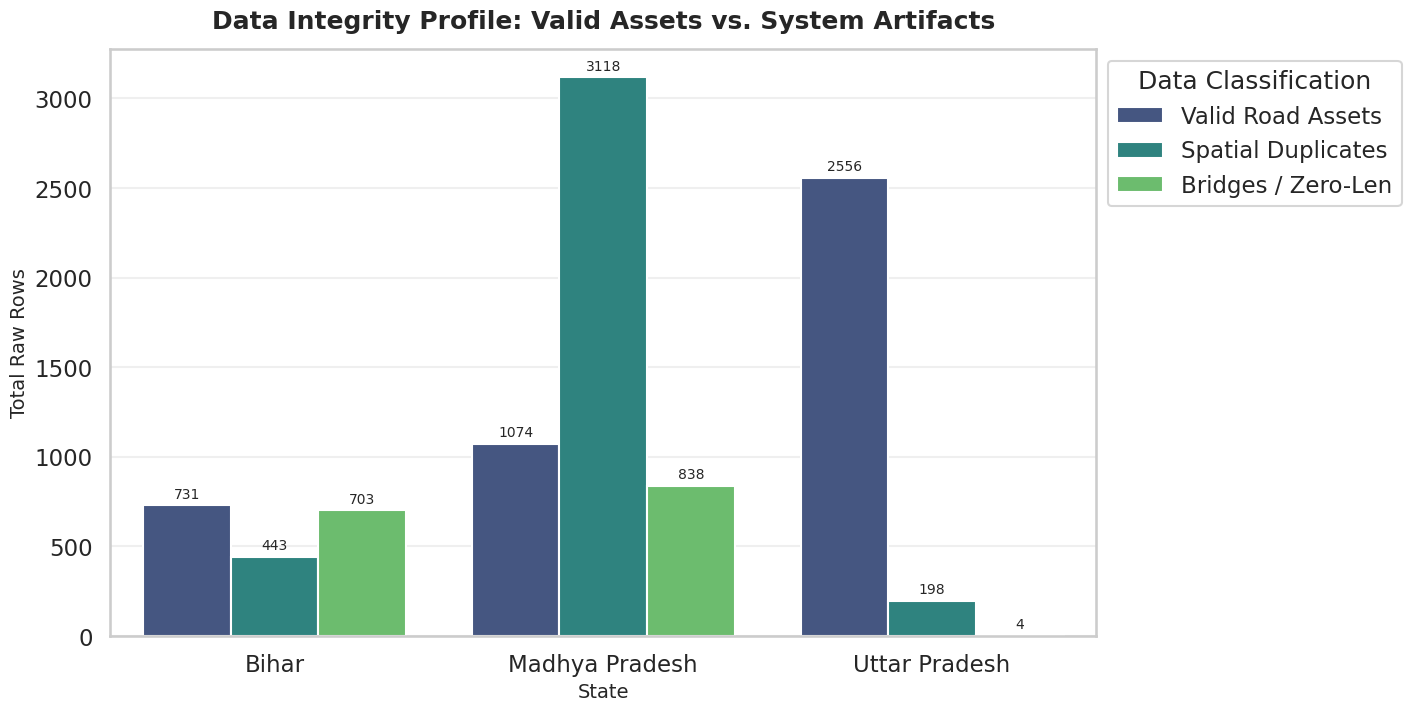


📋 Exact Composition Ledger:
--------------------------------------------------------------------------------
    STATE_NAME  Valid Road Assets  Spatial Duplicates  Bridges / Zero-Len
         Bihar                731                 443                 703
Madhya Pradesh               1074                3118                 838
 Uttar Pradesh               2556                 198                   4


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("="*80)
print("📊 5. DATA COMPOSITION & ARTIFACT PROFILING")
print("="*80)

# 1. Load Data
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip() # Normalize headers
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: File not found.")
    exit()

# 2. Forensic Tagging (Create Boolean Flags)
# Tag A: Duplicates (MP Fragmentation)
# keep='first' means the 1st row is False (Valid), subsequent repetitions are True (Duplicates)
df['IS_DUPLICATE'] = df.duplicated(subset=['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L'], keep='first')

# Tag B: Bridges/Zeros (Not Roads)
# Check for 'L' tag OR near-zero length
if 'PROPOSAL_T' in df.columns:
    df['IS_BRIDGE'] = (df['PROPOSAL_T'] == 'L') | (df['PROPOSED_L'] <= 0.05)
else:
    df['IS_BRIDGE'] = (df['PROPOSED_L'] <= 0.05)

# Tag C: Valid Roads (The leftovers)
# A row is valid only if it is NOT a duplicate AND NOT a bridge
df['IS_VALID_ROAD'] = (~df['IS_DUPLICATE']) & (~df['IS_BRIDGE'])

# 3. Aggregation by State
composition = df.groupby('STATE_NAME')[['IS_VALID_ROAD', 'IS_DUPLICATE', 'IS_BRIDGE']].sum().reset_index()

# Rename for clean plot labels
composition_clean = composition.rename(columns={
    'IS_VALID_ROAD': 'Valid Road Assets',
    'IS_DUPLICATE': 'Spatial Duplicates',
    'IS_BRIDGE': 'Bridges / Zero-Len'
})

# Melt for Seaborn (Wide to Long format)
composition_melted = composition_clean.melt(
    id_vars='STATE_NAME',
    var_name='Category',
    value_name='Row_Count'
)

# 4. Visualization
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

# Stacked Bar Chart workaround using standard Barplot with hue
sns.barplot(
    data=composition_melted,
    x='STATE_NAME',
    y='Row_Count',
    hue='Category',
    palette='viridis',
    ax=ax
)

ax.set_title("Data Integrity Profile: Valid Assets vs. System Artifacts", fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel("Total Raw Rows", fontsize=14)
ax.set_xlabel("State", fontsize=14)
ax.legend(title="Data Classification", bbox_to_anchor=(1, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

plt.show()

# 5. Print the Exact Ledger
print("\n📋 Exact Composition Ledger:")
print("-" * 80)
print(composition_clean.to_string(index=False))
print("="*80)


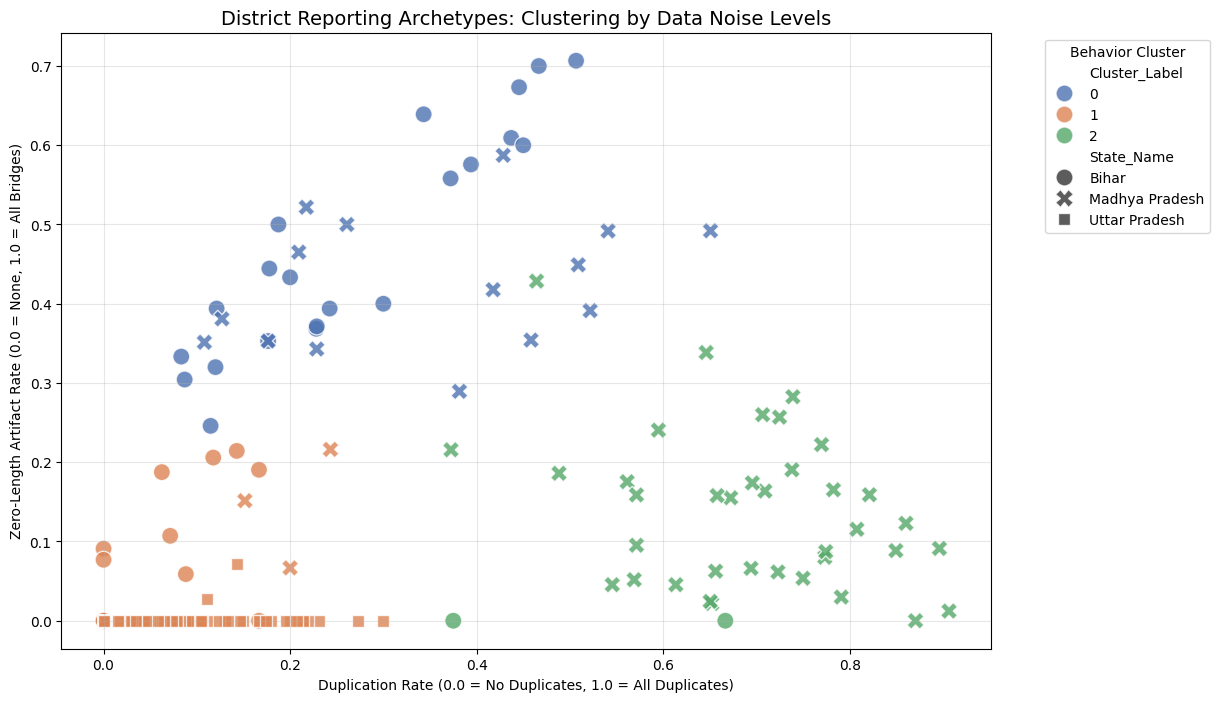

📊 CLUSTER INTERPRETATION (Mean Values)
               Duplicate_Rate  Zero_Length_Rate  Avg_Proposal_Size
Cluster_Label                                                     
0                    0.303296          0.453113           5.379547
1                    0.076780          0.017909           7.453924
2                    0.684959          0.130393          11.509562


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Create a "Data Quality Profile" for each District
district_quality = df.groupby(['State_Name', 'DISTRICT_I']).agg(
    Total_Entries=('PROPOSED_L', 'count'),
    Duplicate_Rate=('Is_Duplicate', 'mean'),  # % of rows that are duplicates
    Zero_Length_Rate=('Is_Bridge_Zero', 'mean'), # % of rows that are 0.0 KM
    Avg_Proposal_Size=('PROPOSED_L', 'mean')
).reset_index()

# 2. Scale the Features (Important because percentages are 0-1, counts are 0-100s)
features = ['Duplicate_Rate', 'Zero_Length_Rate', 'Avg_Proposal_Size']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_quality[features])

# 3. Run K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_quality['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# 4. Visualization: The "Behavior Map"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=district_quality,
    x='Duplicate_Rate',
    y='Zero_Length_Rate',
    hue='Cluster_Label',
    style='State_Name',
    s=150, palette='deep', alpha=0.8
)

plt.title("District Reporting Archetypes: Clustering by Data Noise Levels", fontsize=14)
plt.xlabel("Duplication Rate (0.0 = No Duplicates, 1.0 = All Duplicates)")
plt.ylabel("Zero-Length Artifact Rate (0.0 = None, 1.0 = All Bridges)")
plt.legend(title='Behavior Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Interpret the Clusters for your Log
print("="*50)
print("📊 CLUSTER INTERPRETATION (Mean Values)")
print("="*50)
print(district_quality.groupby('Cluster_Label')[features].mean())


🧩 6. UNSUPERVISED DISTRICT CLUSTERING (Data Quality Archetypes)


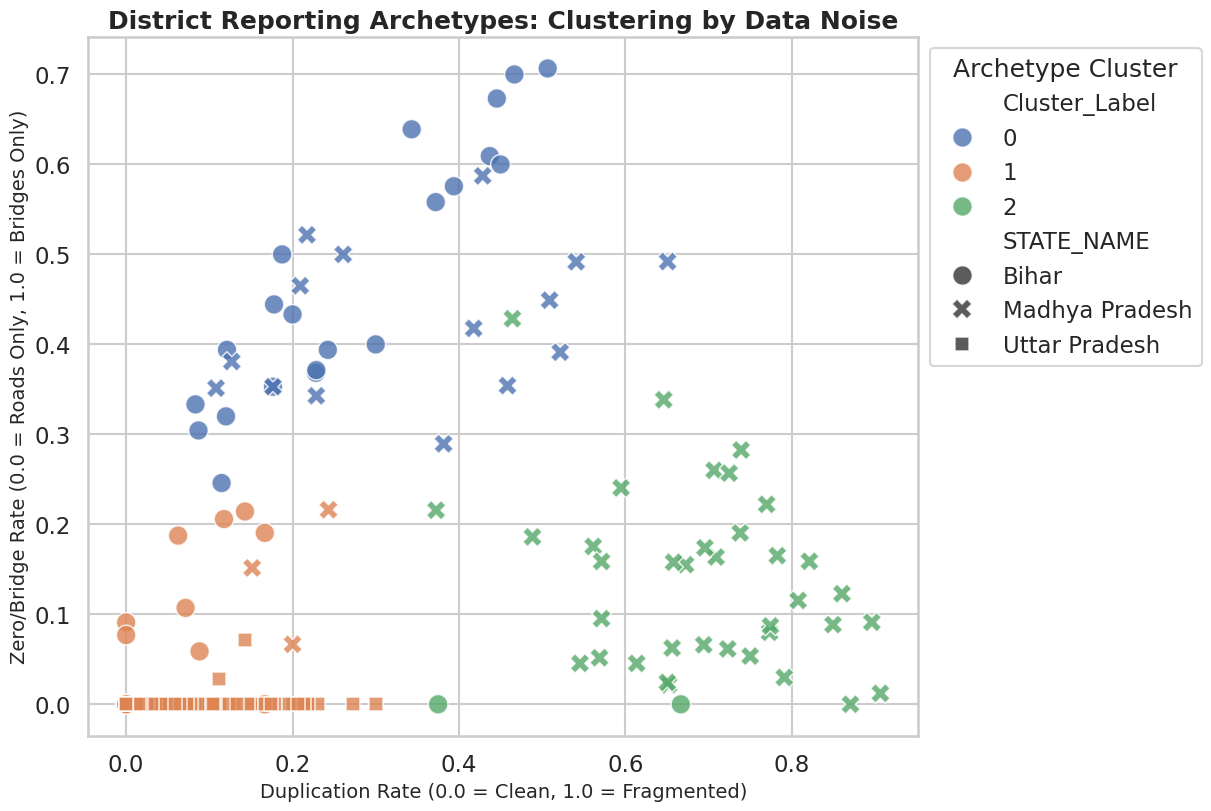


📋 CLUSTER DEFINITIONS (Mean Values):
--------------------------------------------------------------------------------
               Duplicate_Rate  Zero_Length_Rate  Avg_Proposal_Size
Cluster_Label                                                     
0                        0.30              0.45               5.38
1                        0.08              0.02               7.45
2                        0.68              0.13              11.51
--------------------------------------------------------------------------------
💡 INTERPRETATION GUIDE:
   • High Duplicate Rate? -> Likely Madhya Pradesh (Fragmentation Issue)
   • High Zero Rate?      -> Likely Bihar/UP Floodplains (Bridge Intensive)
   • Low on Both?         -> The 'Clean' Districts


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("="*80)
print("🧩 6. UNSUPERVISED DISTRICT CLUSTERING (Data Quality Archetypes)")
print("="*80)

# 1. Load Data & Prep (Robust)
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip()
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: Data file not found.")
    exit()

# 2. Re-Generate Boolean Flags (In case previous cells were skipped)
# Flag A: Duplicates (Same Name + Block + Length)
df['IS_DUPLICATE'] = df.duplicated(subset=['WORK_NAME', 'BLOCK_ID', 'PROPOSED_L'], keep='first')
# Flag B: Bridges/Zeros
if 'PROPOSAL_T' in df.columns:
    df['IS_BRIDGE'] = (df['PROPOSAL_T'] == 'L') | (df['PROPOSED_L'] <= 0.05)
else:
    df['IS_BRIDGE'] = (df['PROPOSED_L'] <= 0.05)

# 3. Feature Engineering: Create District Profiles
# We collapse the 8,000 rows into ~150 District "Personalities"
district_profile = df.groupby(['STATE_NAME', 'DISTRICT_I']).agg(
    Total_Entries=('PROPOSED_L', 'count'),
    Duplicate_Rate=('IS_DUPLICATE', 'mean'),  # % of rows that are duplicates
    Zero_Length_Rate=('IS_BRIDGE', 'mean'),   # % of rows that are bridges/zeros
    Avg_Proposal_Size=('PROPOSED_L', 'mean')  # Do they build big or small?
).reset_index()

# 4. Scale the Features (Critical for K-Means)
features = ['Duplicate_Rate', 'Zero_Length_Rate', 'Avg_Proposal_Size']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_profile[features])

# 5. Run K-Means (k=3)
# We look for 3 Archetypes: "The Clean", "The Fragmented", "The Bridge Heavy"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_profile['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# 6. Visualization: The "Behavior Map"
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

sns.scatterplot(
    data=district_profile,
    x='Duplicate_Rate',
    y='Zero_Length_Rate',
    hue='Cluster_Label',
    style='STATE_NAME',    # Different shapes for different states
    palette='deep',
    s=200,                 # Big dots
    alpha=0.8,
    ax=ax
)

ax.set_title("District Reporting Archetypes: Clustering by Data Noise", fontsize=18, fontweight='bold')
ax.set_xlabel("Duplication Rate (0.0 = Clean, 1.0 = Fragmented)", fontsize=14)
ax.set_ylabel("Zero/Bridge Rate (0.0 = Roads Only, 1.0 = Bridges Only)", fontsize=14)

# Place legend outside
ax.legend(title='Archetype Cluster', bbox_to_anchor=(1, 1), loc='upper left')

plt.show()

# 7. Interpret the Clusters (The "Cheat Sheet")
print("\n📋 CLUSTER DEFINITIONS (Mean Values):")
print("-" * 80)
# Group by Cluster to see what defines them
cluster_stats = district_profile.groupby('Cluster_Label')[features].mean()
print(cluster_stats.to_string(float_format="{:.2f}".format))
print("-" * 80)
print("💡 INTERPRETATION GUIDE:")
print("   • High Duplicate Rate? -> Likely Madhya Pradesh (Fragmentation Issue)")
print("   • High Zero Rate?      -> Likely Bihar/UP Floodplains (Bridge Intensive)")
print("   • Low on Both?         -> The 'Clean' Districts")
print("="*80)


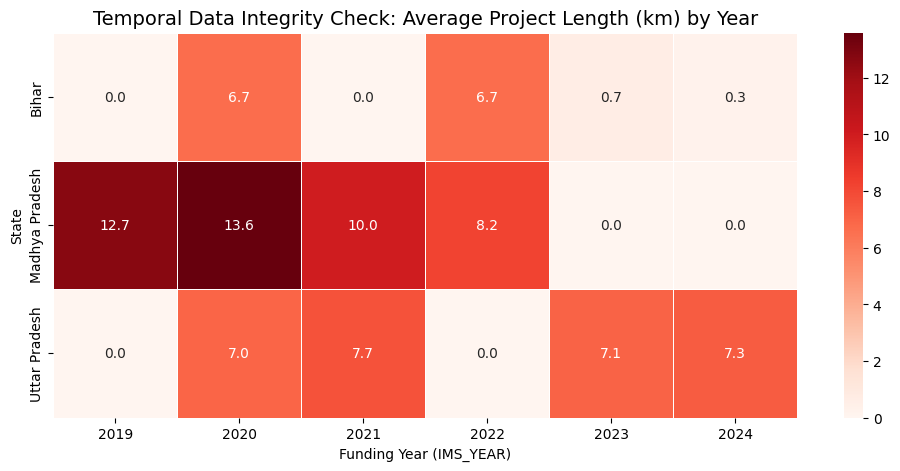

In [ ]:
# Create a Pivot Table: Average Road Length by State vs. Year
temporal_integrity = df.pivot_table(
    index='State_Name',
    columns='IMS_YEAR',
    values='PROPOSED_L',
    aggfunc='mean'
).fillna(0) # Fill missing years with 0

plt.figure(figsize=(12, 5))
sns.heatmap(temporal_integrity, annot=True, fmt=".1f", cmap="Reds", linewidths=.5)
plt.title("Temporal Data Integrity Check: Average Project Length (km) by Year", fontsize=14)
plt.xlabel("Funding Year (IMS_YEAR)")
plt.ylabel("State")
plt.show()


📅 7. TEMPORAL DATA INTEGRITY HEATMAP
ℹ️ Scope: Linear Roads Only (Bridges Excluded for accurate averaging)


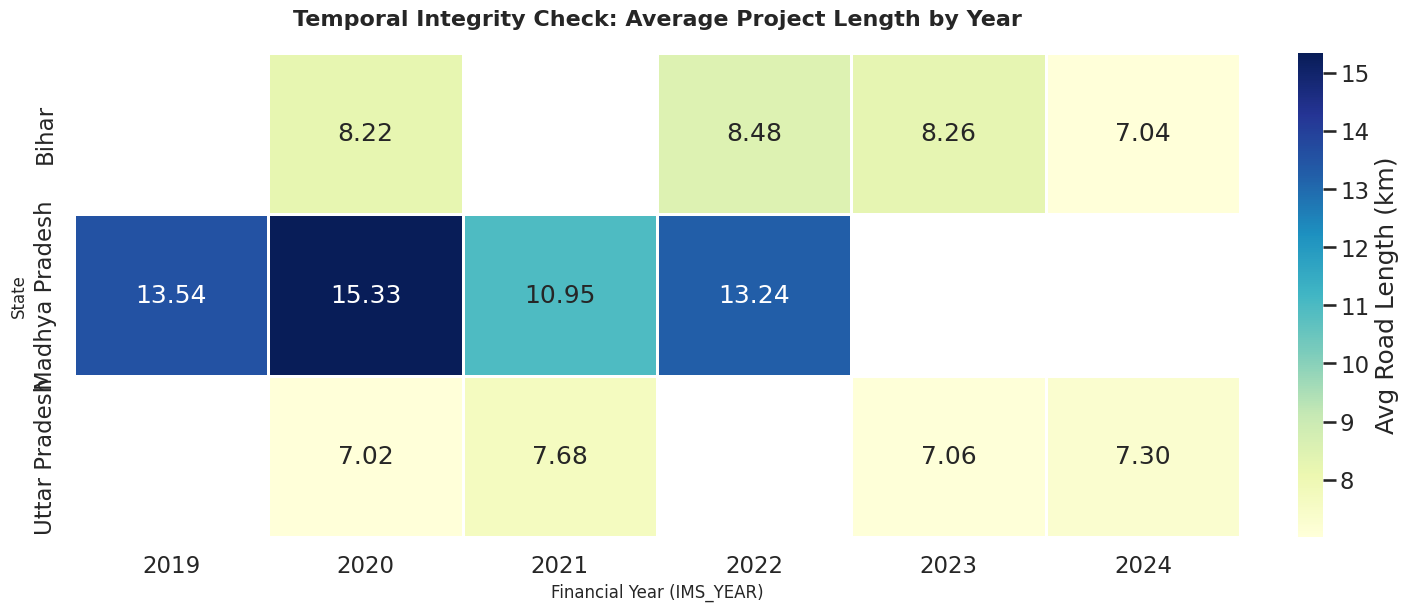


📋 Exact Data Matrix (Avg KM):
--------------------------------------------------------------------------------
IMS_YEAR         2019   2020   2021   2022  2023  2024
STATE_NAME                                            
Bihar             NaN   8.22    NaN   8.48  8.26  7.04
Madhya Pradesh  13.54  15.33  10.95  13.24   NaN   NaN
Uttar Pradesh     NaN   7.02   7.68    NaN  7.06  7.30


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("="*80)
print("📅 7. TEMPORAL DATA INTEGRITY HEATMAP")
print("="*80)

# 1. Load Data
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip()
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: File not found.")
    exit()

# 2. Filter: Roads Only (Proposal_T = 'P')
# We exclude bridges because they drag the average down to near-zero.
if 'PROPOSAL_T' in df.columns:
    heatmap_df = df[df['PROPOSAL_T'] == 'P'].copy()
    print("ℹ️ Scope: Linear Roads Only (Bridges Excluded for accurate averaging)")
else:
    heatmap_df = df.copy()

# 3. Create Pivot Table
# Rows: State | Columns: Year | Values: Average Length
temporal_matrix = heatmap_df.pivot_table(
    index='STATE_NAME',
    columns='IMS_YEAR',
    values='PROPOSED_L',
    aggfunc='mean'
)

# 4. Visualization
sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

sns.heatmap(
    temporal_matrix,
    annot=True,
    fmt=".2f",          # Show 2 decimal places (e.g., 5.43 km)
    cmap="YlGnBu",      # Yellow-Green-Blue (Professional, High contrast)
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Avg Road Length (km)'},
    ax=ax
)

ax.set_title("Temporal Integrity Check: Average Project Length by Year", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Financial Year (IMS_YEAR)", fontsize=12)
ax.set_ylabel("State", fontsize=12)

plt.show()

# 5. Print the Matrix (for your report)
print("\n📋 Exact Data Matrix (Avg KM):")
print("-" * 80)
print(temporal_matrix.round(2).to_string())
print("="*80)


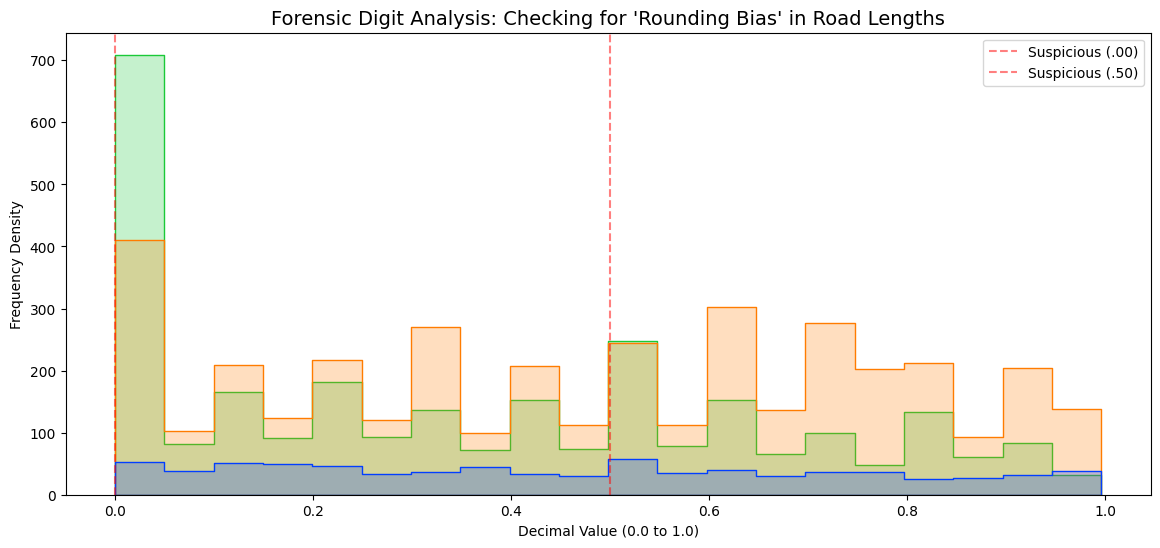

/tmp/ipykernel_1605/1388808281.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


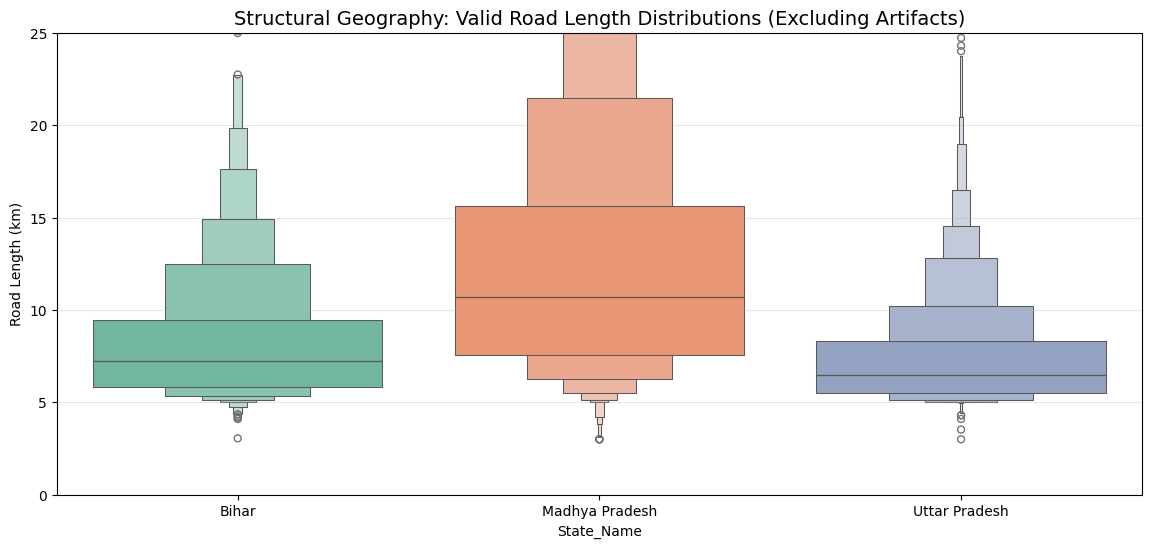

📊 TRUE GEOGRAPHIC BASELINES (Valid Roads Only)
                count  median    mean    std
State_Name                                  
Bihar             773    7.25   8.409  3.766
Madhya Pradesh   3797   10.70  13.082  7.914
Uttar Pradesh    2753    6.50   7.451  2.833


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataframe if not already loaded
# df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# --- EDA PART 1: The "Human Bias" Forensic Test ---
# We extract the DECIMAL part of the road length.
# In genuine GPS data, decimals are random (0.12, 0.98, 0.43).
# In fabricated/estimated data, decimals cluster at .00 and .50.

df_valid = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()
df_valid['Decimal_Part'] = df_valid['PROPOSED_L'] % 1

plt.figure(figsize=(14, 6))
sns.histplot(
    data=df_valid,
    x='Decimal_Part',
    hue='State_Name',
    element="step",
    bins=20,  # 0.00, 0.05, 0.10...
    common_norm=False, # Independent scales so we can compare shapes despite count differences
    palette='bright'
)
plt.title("Forensic Digit Analysis: Checking for 'Rounding Bias' in Road Lengths", fontsize=14)
plt.xlabel("Decimal Value (0.0 to 1.0)")
plt.ylabel("Frequency Density")
plt.axvline(0.0, color='red', linestyle='--', alpha=0.5, label='Suspicious (.00)')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Suspicious (.50)')
plt.legend()
plt.show()

# --- EDA PART 2: The "Plains vs Plateau" Structural Proof ---
# We compare the distribution of VALID roads only.

plt.figure(figsize=(14, 6))

# A Boxen Plot is better than a Box Plot for "Big Data" as it shows tail distributions better
sns.boxenplot(
    data=df_valid,
    x='State_Name',
    y='PROPOSED_L',
    palette='Set2'
)

plt.title("Structural Geography: Valid Road Length Distributions (Excluding Artifacts)", fontsize=14)
plt.ylabel("Road Length (km)")
plt.ylim(0, 25) # Focus on the main body of data
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print the "True" Stats for your Ledger
print("="*60)
print("📊 TRUE GEOGRAPHIC BASELINES (Valid Roads Only)")
print("="*60)
summary = df_valid.groupby('State_Name')['PROPOSED_L'].agg(['count', 'median', 'mean', 'std']).round(3)
print(summary)


🕵️‍♀️ 8. FORENSIC HUMAN BIAS & STRUCTURAL GEOGRAPHY


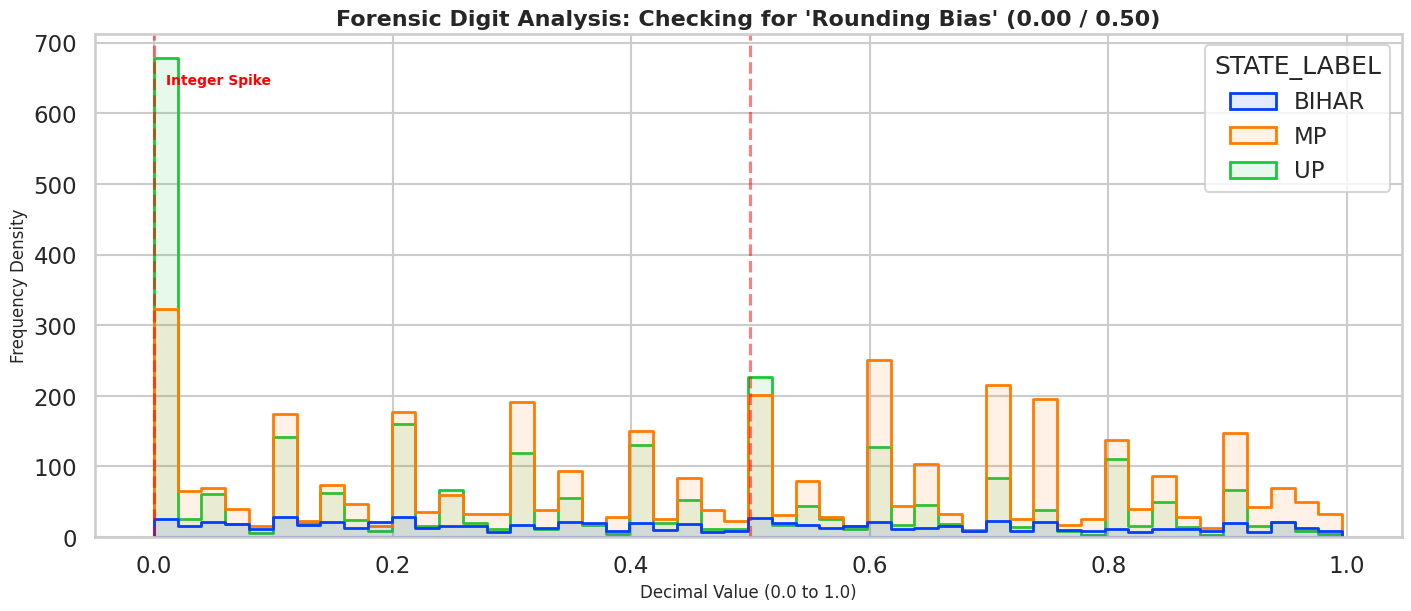

/tmp/ipykernel_638/43537730.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


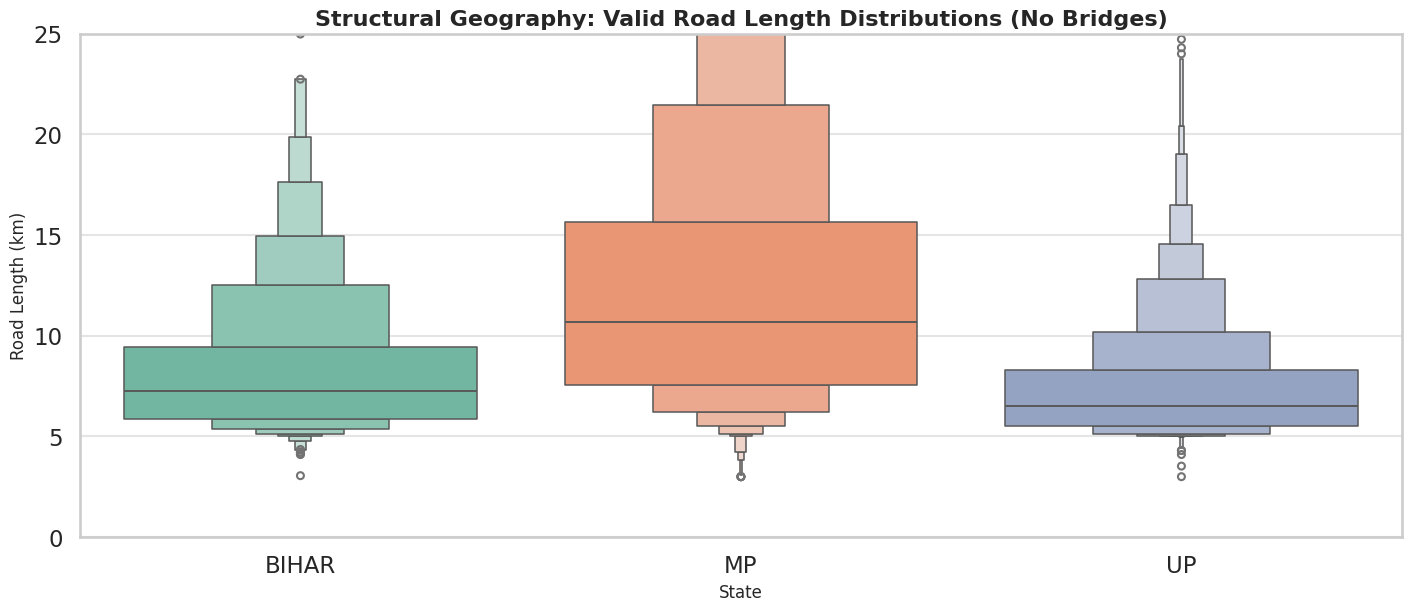


📊 TRUE GEOGRAPHIC BASELINES (Valid Roads Only)
--------------------------------------------------------------------------------
             count  median    mean    std
STATE_LABEL                              
BIHAR          773    7.25   8.409  3.766
MP            3797   10.70  13.082  7.914
UP            2753    6.50   7.451  2.833


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("🕵️‍♀️ 8. FORENSIC HUMAN BIAS & STRUCTURAL GEOGRAPHY")
print("="*80)

# 1. Load & Normalize
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip()
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: File not found.")
    exit()

# 2. Apply Strict State Abbreviations (UP, MP, BIHAR)
state_map = {
    'Uttar Pradesh': 'UP',
    'Madhya Pradesh': 'MP',
    'Bihar': 'BIHAR',
    'UTTAR PRADESH': 'UP',
    'MADHYA PRADESH': 'MP',
    'BIHAR': 'BIHAR'
}
# Create a dedicated display column
df['STATE_LABEL'] = df['STATE_NAME'].map(state_map).fillna(df['STATE_NAME'])

# 3. Filter Valid Roads (Exclude Bridges & Zeros)
if 'PROPOSAL_T' in df.columns:
    df_valid = df[(df['PROPOSED_L'] > 0.05) & (df['PROPOSAL_T'] != 'L')].copy()
else:
    df_valid = df[df['PROPOSED_L'] > 0.05].copy()

# ---------------------------------------------------------
# PLOT 1: The "Human Bias" Test (Decimal Analysis)
# ---------------------------------------------------------
# Extract the decimal part (e.g., 5.12 -> 0.12)
df_valid['Decimal_Part'] = df_valid['PROPOSED_L'] % 1

sns.set_theme(style="whitegrid", context="talk")
fig1, ax1 = plt.subplots(figsize=(14, 6), constrained_layout=True)

sns.histplot(
    data=df_valid,
    x='Decimal_Part',
    hue='STATE_LABEL',
    element="step",
    bins=50,             # High res to see the spikes
    common_norm=False,   # Compare shapes, not total volume
    palette='bright',    # YOUR CHOICE: Bright colors
    linewidth=2,
    alpha=0.1,
    ax=ax1
)

ax1.set_title("Forensic Digit Analysis: Checking for 'Rounding Bias' (0.00 / 0.50)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Decimal Value (0.0 to 1.0)", fontsize=12)
ax1.set_ylabel("Frequency Density", fontsize=12)

# Mark the suspicious zones
ax1.axvline(0.0, color='red', linestyle='--', alpha=0.5)
ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax1.text(0.01, ax1.get_ylim()[1]*0.9, 'Integer Spike', color='red', fontsize=10, fontweight='bold')

plt.show()

# ---------------------------------------------------------
# PLOT 2: Structural Geography (Boxen Plot)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 6), constrained_layout=True)

# Boxen plots are superior for datasets > 5,000 rows
sns.boxenplot(
    data=df_valid,
    x='STATE_LABEL',
    y='PROPOSED_L',
    palette='Set2',      # YOUR CHOICE: Set2 colors
    ax=ax2
)

ax2.set_title("Structural Geography: Valid Road Length Distributions (No Bridges)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Road Length (km)", fontsize=12)
ax2.set_xlabel("State", fontsize=12)
ax2.set_ylim(0, 25) # Focus on main body (zoom in)
ax2.grid(axis='y', alpha=0.5)

plt.show()

# ---------------------------------------------------------
# STATS LEDGER
# ---------------------------------------------------------
print("\n📊 TRUE GEOGRAPHIC BASELINES (Valid Roads Only)")
print("-" * 80)
summary = df_valid.groupby('STATE_LABEL')['PROPOSED_L'].agg(['count', 'median', 'mean', 'std']).round(3)
print(summary.to_string())
print("="*80)


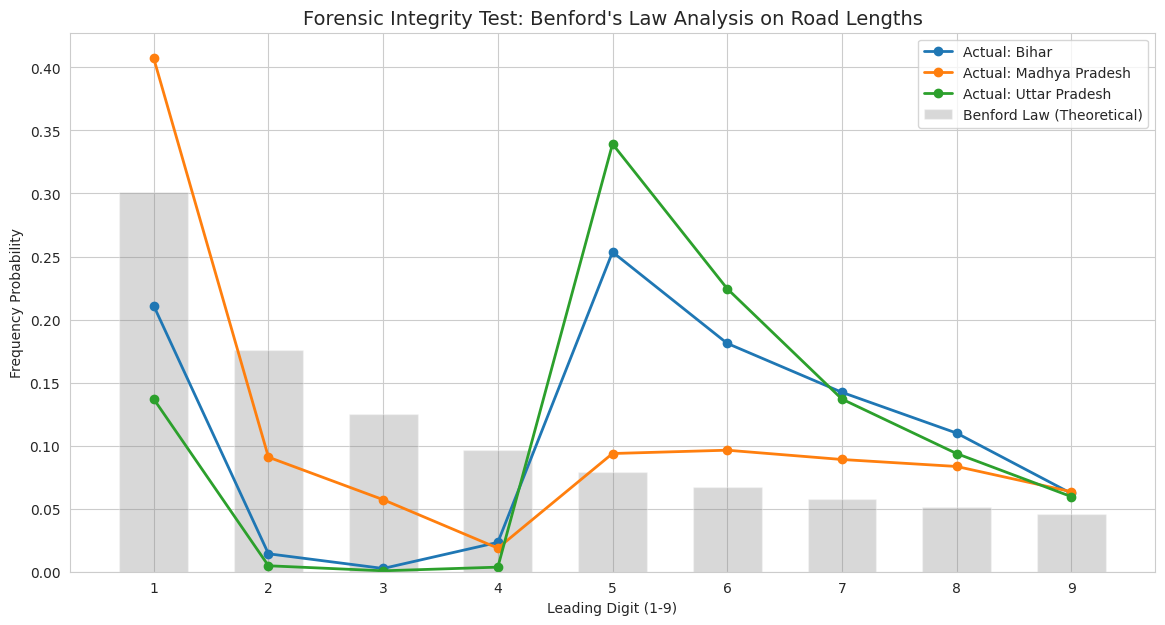

🔍 BENFORD COMPLIANCE SCORE (RMSE)
Lower is Better. > 0.05 indicates potential manipulation/estimation.
         State  Benford_RMSE
 Uttar Pradesh        0.1419
         Bihar        0.1100
Madhya Pradesh        0.0602


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load Data (Assuming df is active, if not reload it)
# df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# 1. Filter for VALID roads only (Non-zero, Non-Bridge)
df_benford = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# 2. Extract the Leading Digit (1-9)
# Convert length to string, take first character, ensure it's not '0' or '.'
def get_leading_digit(x):
    try:
        s = str(float(x))
        # Handle cases like 0.5 (leading digit should be 5 in scientific notation, or skip <1)
        # For simplicity in road lengths > 1km, we just take the first non-zero digit
        for char in s:
            if char in '123456789':
                return int(char)
        return np.nan
    except:
        return np.nan

df_benford['First_Digit'] = df_benford['PROPOSED_L'].apply(get_leading_digit)
df_benford = df_benford.dropna(subset=['First_Digit']) # Drop roads < 1km or errors

# 3. Calculate Benford's Expected Frequencies
benford_digits = list(range(1, 10))
benford_probs = [math.log10(1 + 1/d) for d in benford_digits] # The Law [30.1%, 17.6%...]

# 4. Calculate Actual Frequencies per State
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# We create a custom plot for each state to compare
states = df_benford['State_Name'].unique()
colors = ['blue', 'green', 'orange']

for i, state in enumerate(states):
    state_data = df_benford[df_benford['State_Name'] == state]
    counts = state_data['First_Digit'].value_counts(normalize=True).sort_index()

    # Fill missing digits with 0
    for d in range(1, 10):
        if d not in counts:
            counts[d] = 0

    # Plot the Actuals as Lines
    plt.plot(counts.index, counts.values, marker='o', linestyle='-', linewidth=2, label=f"Actual: {state}")

# Plot the Theoretical Benford Law (The Control)
plt.bar(benford_digits, benford_probs, color='gray', alpha=0.3, label='Benford Law (Theoretical)', width=0.6)

plt.title("Forensic Integrity Test: Benford's Law Analysis on Road Lengths", fontsize=14)
plt.xlabel("Leading Digit (1-9)")
plt.ylabel("Frequency Probability")
plt.xticks(benford_digits)
plt.legend()
plt.show()

# 5. Print the Deviation Score (RMSE) for the Ledger
print("="*60)
print("🔍 BENFORD COMPLIANCE SCORE (RMSE)")
print("Lower is Better. > 0.05 indicates potential manipulation/estimation.")
print("="*60)

results = []
for state in states:
    state_data = df_benford[df_benford['State_Name'] == state]
    actuals = state_data['First_Digit'].value_counts(normalize=True).sort_index()

    # Re-index to ensure 1-9 match
    actual_vector = [actuals.get(d, 0) for d in benford_digits]

    # Calculate Root Mean Square Error (RMSE)
    rmse = math.sqrt(sum((a - b)**2 for a, b in zip(actual_vector, benford_probs)) / 9)
    results.append({'State': state, 'Benford_RMSE': round(rmse, 4)})

print(pd.DataFrame(results).sort_values(by='Benford_RMSE', ascending=False).to_string(index=False))


🔍 9. BENFORD'S LAW FORENSIC TEST


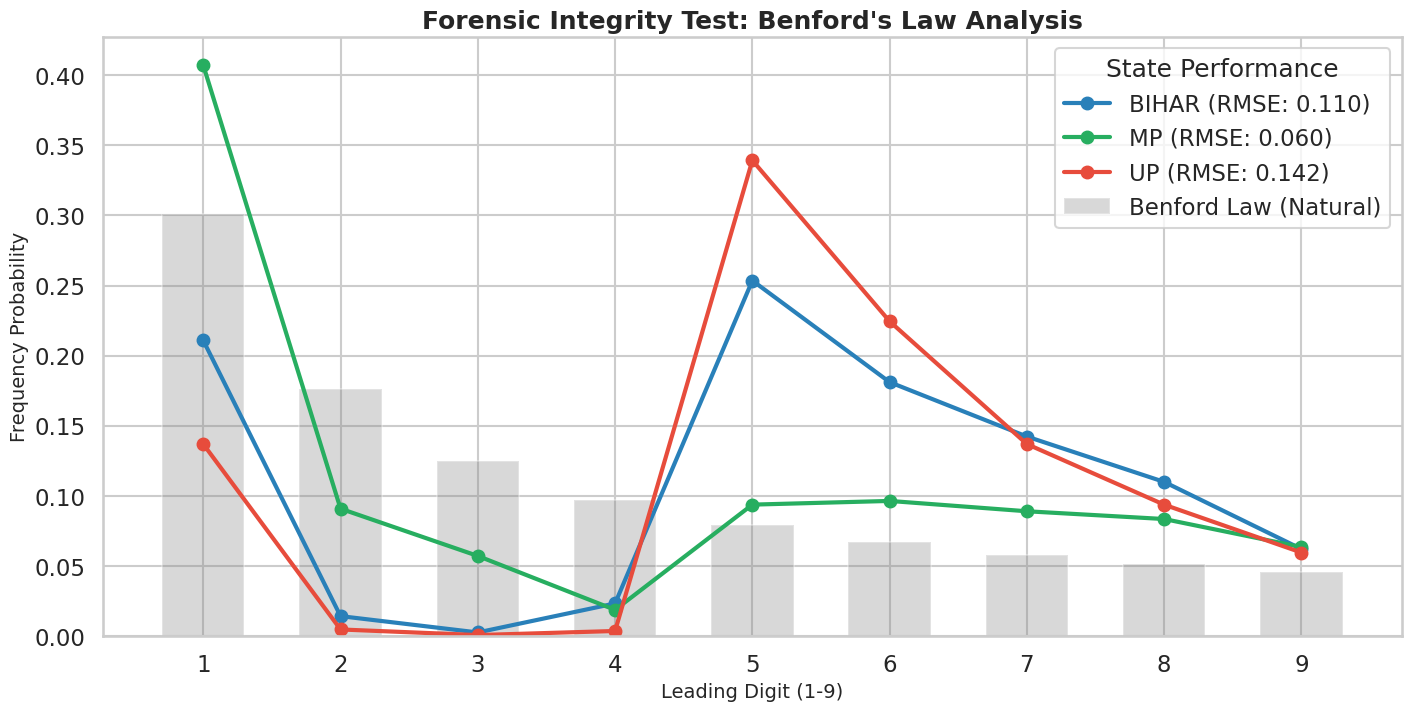


📊 BENFORD COMPLIANCE LEDGER (RMSE SCORE)
------------------------------------------------------------
State  Benford_RMSE
   UP      0.141860
BIHAR      0.110047
   MP      0.060224
------------------------------------------------------------
💡 INTERPRETATION:
   • RMSE < 0.05 : Natural Data (Clean)
   • RMSE > 0.10 : Artificial Data (Likely Estimated/Rounded)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("="*80)
print("🔍 9. BENFORD'S LAW FORENSIC TEST")
print("="*80)

# 1. Load & Prep
try:
    df = pd.read_csv("PMGSY_Master_Dataset_Combined(1).csv")
    df.columns = df.columns.str.upper().str.strip()
    df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
except FileNotFoundError:
    print("❌ ERROR: File not found.")
    exit()

# 2. Apply State Abbreviations
state_map = {'Uttar Pradesh': 'UP', 'Madhya Pradesh': 'MP', 'Bihar': 'BIHAR',
             'UTTAR PRADESH': 'UP', 'MADHYA PRADESH': 'MP', 'BIHAR': 'BIHAR'}
df['STATE_LABEL'] = df['STATE_NAME'].map(state_map).fillna(df['STATE_NAME'])

# 3. Filter: Valid Roads Only (No Bridges, No Zeros)
# Benford's Law applies to natural magnitudes. 0.0 or 0.5 integers bias the result.
if 'PROPOSAL_T' in df.columns:
    df_benford = df[(df['PROPOSED_L'] > 0.05) & (df['PROPOSAL_T'] != 'L')].copy()
else:
    df_benford = df[df['PROPOSED_L'] > 0.05].copy()

# 4. Extract Leading Digit (The Forensic Feature)
def get_leading_digit(x):
    try:
        s = str(float(x))
        # Scan for first non-zero digit (handles 0.5 -> 5)
        for char in s:
            if char in '123456789':
                return int(char)
        return np.nan
    except:
        return np.nan

df_benford['First_Digit'] = df_benford['PROPOSED_L'].apply(get_leading_digit)
df_benford = df_benford.dropna(subset=['First_Digit'])

# 5. Calculate Probabilities
benford_digits = list(range(1, 10))
benford_probs = [math.log10(1 + 1/d) for d in benford_digits]

# 6. Visualization
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

# Plot Theoretical Bars (The "Law")
ax.bar(benford_digits, benford_probs, color='gray', alpha=0.3, label='Benford Law (Natural)', width=0.6)

# Calculate & Plot Actuals per State
states = df_benford['STATE_LABEL'].unique()
colors = {'UP': '#e74c3c', 'MP': '#27ae60', 'BIHAR': '#2980b9'} # Red (Alert), Green (Safe), Blue (Neutral)

rmse_ledger = []

for state in states:
    state_data = df_benford[df_benford['STATE_LABEL'] == state]
    counts = state_data['First_Digit'].value_counts(normalize=True).sort_index()

    # Ensure all digits 1-9 exist
    counts = counts.reindex(benford_digits, fill_value=0)

    # Calculate RMSE (Deviation Score)
    actual_vector = counts.values
    rmse = math.sqrt(sum((a - b)**2 for a, b in zip(actual_vector, benford_probs)) / 9)
    rmse_ledger.append({'State': state, 'Benford_RMSE': rmse})

    # Plot Line
    ax.plot(
        counts.index,
        counts.values,
        marker='o',
        linestyle='-',
        linewidth=3,
        color=colors.get(state, 'black'),
        label=f"{state} (RMSE: {rmse:.3f})"
    )

ax.set_title("Forensic Integrity Test: Benford's Law Analysis", fontsize=18, fontweight='bold')
ax.set_xlabel("Leading Digit (1-9)", fontsize=14)
ax.set_ylabel("Frequency Probability", fontsize=14)
ax.set_xticks(benford_digits)
ax.legend(title="State Performance")

plt.show()

# 7. Print Ledger
print("\n📊 BENFORD COMPLIANCE LEDGER (RMSE SCORE)")
print("-" * 60)
results_df = pd.DataFrame(rmse_ledger).sort_values(by='Benford_RMSE', ascending=False)
print(results_df.to_string(index=False))
print("-" * 60)
print("💡 INTERPRETATION:")
print("   • RMSE < 0.05 : Natural Data (Clean)")
print("   • RMSE > 0.10 : Artificial Data (Likely Estimated/Rounded)")
print("="*80)


/tmp/ipykernel_1605/2312712136.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


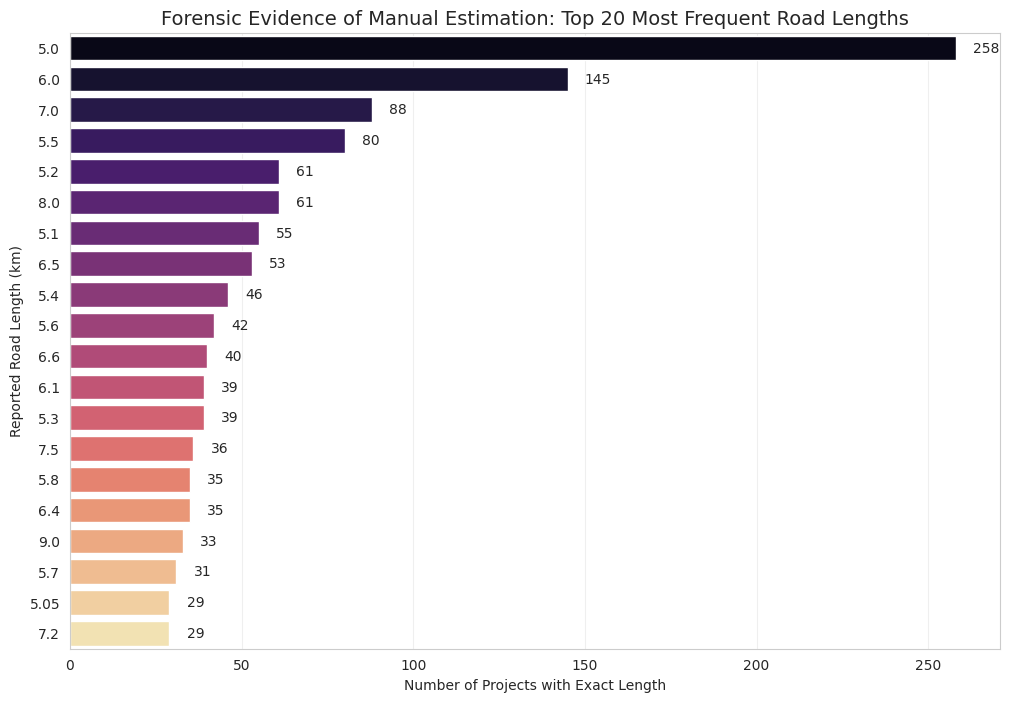

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for the "Guilty" States
guilty_data = df_benford[df_benford['State_Name'].isin(['Uttar Pradesh', 'Bihar'])]

# 2. Get the Top 20 most frequent specific lengths
# We count exact occurrences of each length value
top_values = guilty_data['PROPOSED_L'].value_counts().head(20).reset_index()
top_values.columns = ['Road_Length', 'Frequency_Count']

# 3. The Scientific Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_values,
    y='Road_Length',
    x='Frequency_Count',
    orient='h',
    palette='magma',
    order=top_values['Road_Length'] # Ensure sorted order
)

plt.title("Forensic Evidence of Manual Estimation: Top 20 Most Frequent Road Lengths", fontsize=14)
plt.xlabel("Number of Projects with Exact Length")
plt.ylabel("Reported Road Length (km)")
plt.grid(axis='x', alpha=0.3)

# Add text labels to show the exact scale of the "Cheat"
for index, value in enumerate(top_values['Frequency_Count']):
    plt.text(value + 5, index, str(value), va='center')

plt.show()


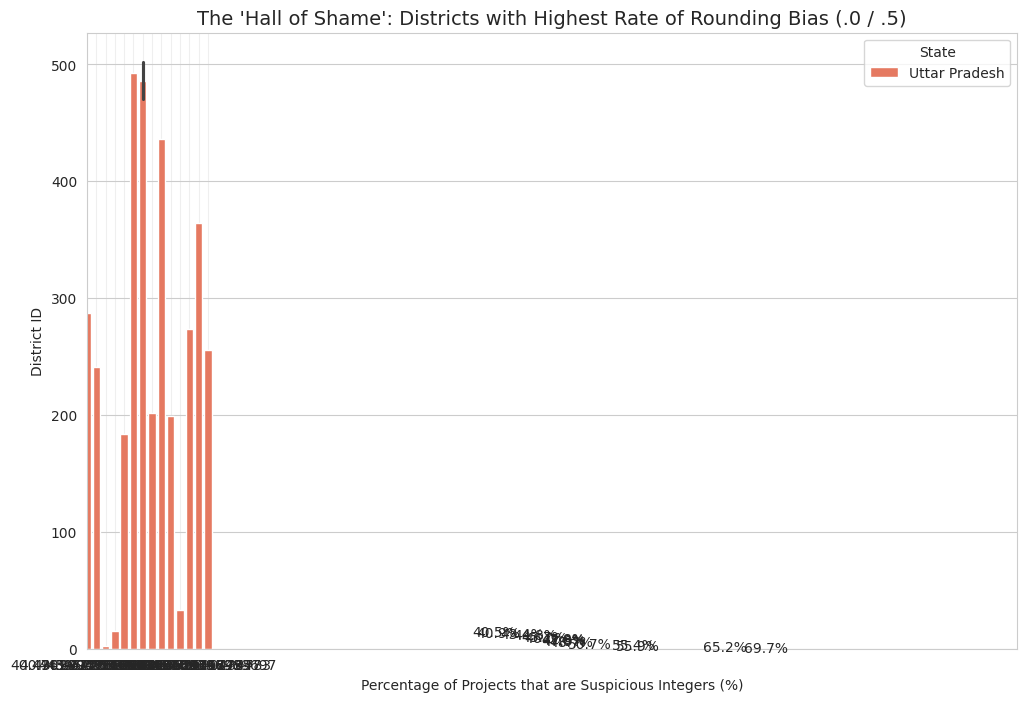

📋 TOP 5 DISTRICTS WITH HIGHEST ESTIMATION BIAS
   State_Name  DISTRICT_I  Total_Projects  Laziness_Score_Pct
Uttar Pradesh         256              33           69.696970
Uttar Pradesh         364              23           65.217391
Uttar Pradesh         274              34           55.882353
Uttar Pradesh          33              83           55.421687
Uttar Pradesh         199              67           50.746269


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Master File
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# 2. Create a temporary analysis frame
# We MUST exclude Long Span Bridges (Proposal_T == 'L') and 0.0 lengths.
# Why? Because bridges are hardcoded as "0.0", which is an integer.
# Including them would falsely flag honest districts as "lazy."
df_analysis = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# 3. Flag the "Suspicious Integers"
# We look for lengths where the decimal is exactly .0 or .5
df_analysis['Is_Suspicious_Integer'] = df_analysis['PROPOSED_L'].apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5))

# 4. Group by District to find the "Worst Offenders"
offender_table = df_analysis.groupby(['State_Name', 'DISTRICT_I']).agg(
    Total_Projects=('PROPOSED_L', 'count'),
    Suspicious_Count=('Is_Suspicious_Integer', 'sum')
).reset_index()

# 5. Calculate the "Laziness Score" (%)
offender_table['Laziness_Score_Pct'] = (offender_table['Suspicious_Count'] / offender_table['Total_Projects']) * 100

# Filter: Only show districts with enough data (>20 projects) to be statistically significant
major_offenders = offender_table[offender_table['Total_Projects'] > 20].sort_values(by='Laziness_Score_Pct', ascending=False)

# 6. Plot the "Hall of Shame"
plt.figure(figsize=(12, 8))
sns.barplot(
    data=major_offenders.head(15),
    x='Laziness_Score_Pct',
    y='DISTRICT_I',
    hue='State_Name',
    dodge=False,
    palette='Reds_r'
)

plt.title("The 'Hall of Shame': Districts with Highest Rate of Rounding Bias (.0 / .5)", fontsize=14)
plt.xlabel("Percentage of Projects that are Suspicious Integers (%)")
plt.ylabel("District ID")
plt.xlim(0, 100)
plt.legend(title='State')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for index, row in major_offenders.head(15).reset_index().iterrows():
    plt.text(row['Laziness_Score_Pct'] + 1, index, f"{row['Laziness_Score_Pct']:.1f}%", va='center')

plt.show()

print("="*60)
print("📋 TOP 5 DISTRICTS WITH HIGHEST ESTIMATION BIAS")
print("="*60)
print(major_offenders.head(5)[['State_Name', 'DISTRICT_I', 'Total_Projects', 'Laziness_Score_Pct']].to_string(index=False))



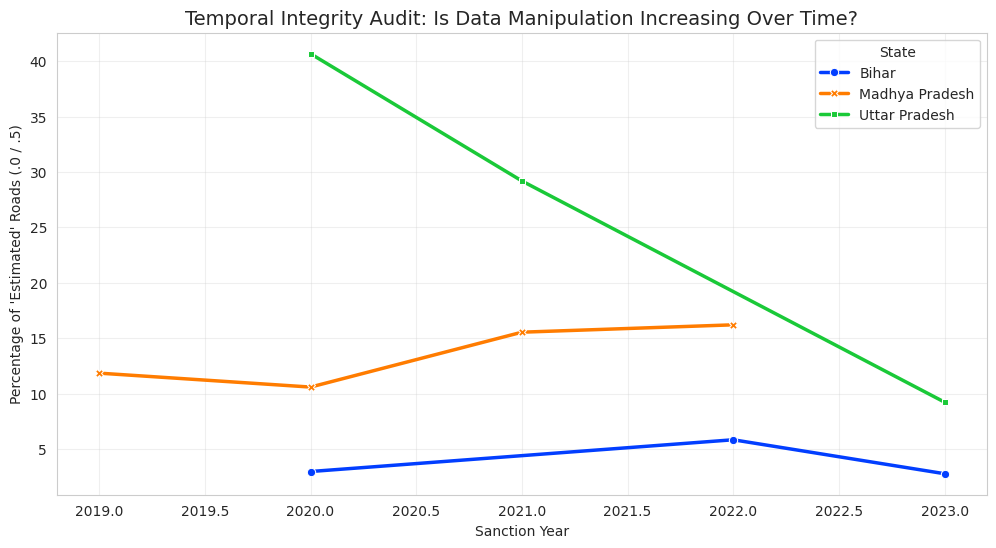

📊 YEAR-OVER-YEAR ESTIMATION TRENDS
State_Name  Bihar  Madhya Pradesh  Uttar Pradesh
IMS_YEAR                                        
2019          NaN            11.9            NaN
2020          3.0            10.6           40.7
2021          NaN            15.5           29.2
2022          5.8            16.2            NaN
2023          2.8             NaN            9.2


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data (if needed)
# df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# 2. Filter for Valid Roads (No Bridges)
df_trend = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# 3. Tag Suspicious Rows (.0 or .5)
df_trend['Is_Suspicious'] = df_trend['PROPOSED_L'].apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5))

# 4. Group by State and Year
temporal_trend = df_trend.groupby(['State_Name', 'IMS_YEAR']).agg(
    Total_Projects=('PROPOSED_L', 'count'),
    Suspicious_Count=('Is_Suspicious', 'sum')
).reset_index()

# Calculate % Laziness per Year
temporal_trend['Laziness_Pct'] = (temporal_trend['Suspicious_Count'] / temporal_trend['Total_Projects']) * 100

# Filter out empty years (2023/2024 zero-data years)
temporal_trend = temporal_trend[temporal_trend['Total_Projects'] > 10]

# 5. Plot the Timeline of Fraud
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=temporal_trend,
    x='IMS_YEAR',
    y='Laziness_Pct',
    hue='State_Name',
    style='State_Name',
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette='bright'
)

plt.title("Temporal Integrity Audit: Is Data Manipulation Increasing Over Time?", fontsize=14)
plt.ylabel("Percentage of 'Estimated' Roads (.0 / .5)")
plt.xlabel("Sanction Year")
plt.grid(True, alpha=0.3)
plt.legend(title='State')
plt.show()

print("="*60)
print("📊 YEAR-OVER-YEAR ESTIMATION TRENDS")
print("="*60)
print(temporal_trend.pivot(index='IMS_YEAR', columns='State_Name', values='Laziness_Pct').round(1))


In [ ]:
# 1. Isolate the Worst Offender (District 256 from your previous result)
# (You can change 256 to any ID you saw in your "Hall of Shame" list)
target_id = 256
suspect_district = df[(df['DISTRICT_I'] == target_id) & (df['Proposal_T'] != 'L')]

# 2. Count the exact lengths
ghost_projects = suspect_district['PROPOSED_L'].value_counts().head(10)

print("="*60)
print(f"🕵️‍♀️ FORENSIC DUMP: DISTRICT {target_id} (The Worst Offender)")
print("="*60)
print(f"Total Projects in Registry: {len(suspect_district)}")
print("\nTop 10 Most Frequent Lengths (The 'Copy-Paste' Values):")
print("-" * 40)
print(ghost_projects.to_string())

# 3. Automated Verdict
top_val = ghost_projects.index[0]
top_count = ghost_projects.values[0]
pct = (top_count / len(suspect_district)) * 100
print("-" * 40)
print(f"VERDICT: This district has used the value '{top_val} km' exactly {top_count} times.")
print(f"That single number accounts for {pct:.1f}% of their entire infrastructure plan.")


🕵️‍♀️ FORENSIC DUMP: DISTRICT 256 (The Worst Offender)
Total Projects in Registry: 33

Top 10 Most Frequent Lengths (The 'Copy-Paste' Values):
----------------------------------------
PROPOSED_L
6.0     7
9.0     5
7.0     4
10.0    2
5.1     2
8.0     2
6.5     2
11.0    1
7.4     1
6.6     1
----------------------------------------
VERDICT: This district has used the value '6.0 km' exactly 7 times.
That single number accounts for 21.2% of their entire infrastructure plan.


In [ ]:
# Extract road names from District 256 to hunt for clues
clues = df[df['DISTRICT_I'] == 256]['WORK_NAME'].head(10).tolist()

print("="*60)
print("🔍 IDENTITY HUNT: CLUES FOR DISTRICT 256")
print("="*60)
for i, name in enumerate(clues):
    print(f"{i+1}. {name}")

print("\n💡 HINT: Look at the road names above.")
print("Does a specific city or region name appear frequently? That is likely your district.")


🔍 IDENTITY HUNT: CLUES FOR DISTRICT 256
1. MRL05-NH 25 to Avadhpur
2. MRL07-T01 to Dharampura
3. MRL01-T05 km 12 to Atarsuan
4. MRL01-T02 km36 to Sijaura
5. MRL02-T06 km16 to Simra
6. MRL06-T01 to Gobara
7. MRL03-T03 Kakarbai to Machhli Kanch
8. T01-Raxa to Ambabai
9. MRL04-T-05 to Badanpur
10. MRL05-T04 km 47 to Saiguwan

💡 HINT: Look at the road names above.
Does a specific city or region name appear frequently? That is likely your district.


♻️ FORENSIC AUDIT: RECYCLED PROJECTS (Same Name, Diff Year)
🚨 Total Potentially Recycled Projects Found: 567

📋 Top 5 Most 'Recycled' Road Names (Sanctioned in multiple years):
    State_Name                                     Clean_Name               Years_List
Madhya Pradesh t01-jevanara to dhapara(gangerua) via pipariya [2020, 2021, 2023, 2022]
Madhya Pradesh  t01-barotha khokhariya awaliya pipliya jamgod [2020, 2024, 2022, 2023]
Madhya Pradesh           t08-khadki to chanera jamlikala road       [2021, 2023, 2022]
         Bihar            mrl03-pwd road bela to lohdiha road       [2023, 2024, 2022]
Madhya Pradesh                      t05-mahidpur to nageshwar       [2020, 2019, 2023]

🌉 STRUCTURAL AUDIT: BRIDGE DENSITY vs. GEOGRAPHY
🚨 Anomalous Districts: 19 Districts have >50 Roads but ZERO Bridges.

📋 Top 5 'Bridge-Less' Districts (Potential Template Planning):
    State_Name  DISTRICT_I  Road_Count  Bridge_Count
Madhya Pradesh         508          85             0
 Uttar Prade

/tmp/ipykernel_1605/592974166.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='State_Name', y='Bridge_Density', data=structure_audit, palette='coolwarm')


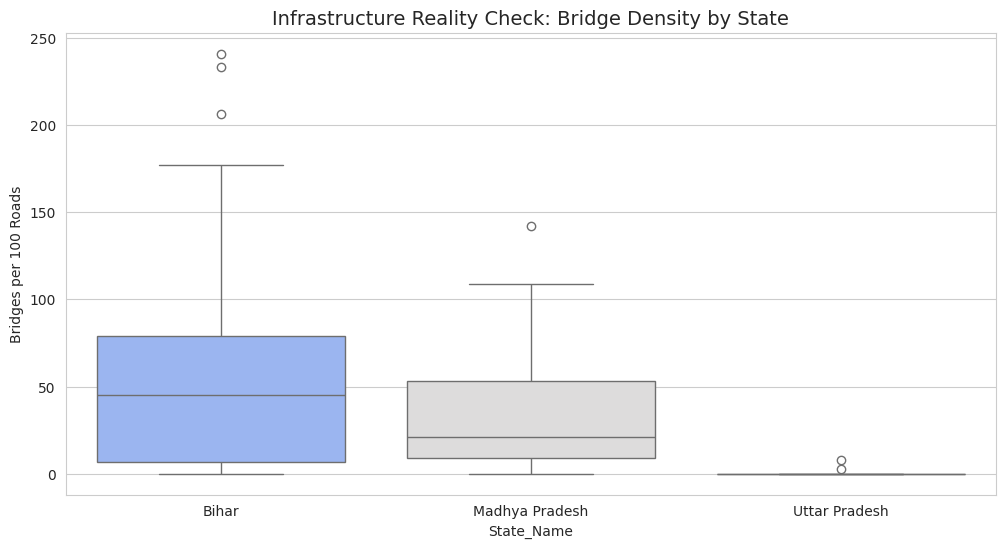

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# ==============================================================================
# 🔍 ANALYSIS 1: THE "RECYCLED ROAD" DETECTOR (Double Dipping)
# ==============================================================================
print("="*60)
print("♻️ FORENSIC AUDIT: RECYCLED PROJECTS (Same Name, Diff Year)")
print("="*60)

# 1. Clean names to ensure "Road A" and "Road A " match
df['Clean_Name'] = df['WORK_NAME'].str.lower().str.strip()

# 2. Find roads that exist in more than one distinct funding year
recycling_audit = df.groupby(['State_Name', 'Clean_Name']).agg(
    Unique_Years=('IMS_YEAR', 'nunique'),
    Years_List=('IMS_YEAR', 'unique'),
    Total_Entries=('IMS_YEAR', 'count')
).reset_index()

# Filter for "Guilty" Roads (Appearing in 2+ different years)
recycled_roads = recycling_audit[recycling_audit['Unique_Years'] > 1].sort_values(by='Unique_Years', ascending=False)

print(f"🚨 Total Potentially Recycled Projects Found: {len(recycled_roads)}")
print("\n📋 Top 5 Most 'Recycled' Road Names (Sanctioned in multiple years):")
print(recycled_roads[['State_Name', 'Clean_Name', 'Years_List']].head(5).to_string(index=False))

# ==============================================================================
# 🔍 ANALYSIS 2: THE "MISSING BRIDGE" ANOMALY (Geographic Mismatch)
# ==============================================================================
print("\n" + "="*60)
print("🌉 STRUCTURAL AUDIT: BRIDGE DENSITY vs. GEOGRAPHY")
print("="*60)

# 1. Calculate Bridge vs. Road counts per District
structure_audit = df.groupby(['State_Name', 'DISTRICT_I', 'Proposal_T']).size().unstack(fill_value=0).reset_index()

# Rename columns (L = Bridge, P = Road)
if 'L' in structure_audit.columns and 'P' in structure_audit.columns:
    structure_audit.rename(columns={'L': 'Bridge_Count', 'P': 'Road_Count'}, inplace=True)

    # 2. Calculate "Bridge Density" (Bridges per 100 Roads)
    structure_audit['Bridge_Density'] = (structure_audit['Bridge_Count'] / structure_audit['Road_Count']) * 100

    # 3. Identify The Anomalies: High Volume Districts (50+ roads) with ZERO bridges
    suspicious_dry = structure_audit[
        (structure_audit['Road_Count'] > 50) &
        (structure_audit['Bridge_Count'] == 0)
    ].sort_values(by='Road_Count', ascending=False)

    print(f"🚨 Anomalous Districts: {len(suspicious_dry)} Districts have >50 Roads but ZERO Bridges.")
    print("\n📋 Top 5 'Bridge-Less' Districts (Potential Template Planning):")
    print(suspicious_dry[['State_Name', 'DISTRICT_I', 'Road_Count', 'Bridge_Count']].head(5).to_string(index=False))

    # 4. Visualizing the Disparity
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='State_Name', y='Bridge_Density', data=structure_audit, palette='coolwarm')
    plt.title("Infrastructure Reality Check: Bridge Density by State", fontsize=14)
    plt.ylabel("Bridges per 100 Roads")
    plt.show()

else:
    print("⚠️ Dataset lacks 'Proposal_T' distinction for this audit.")


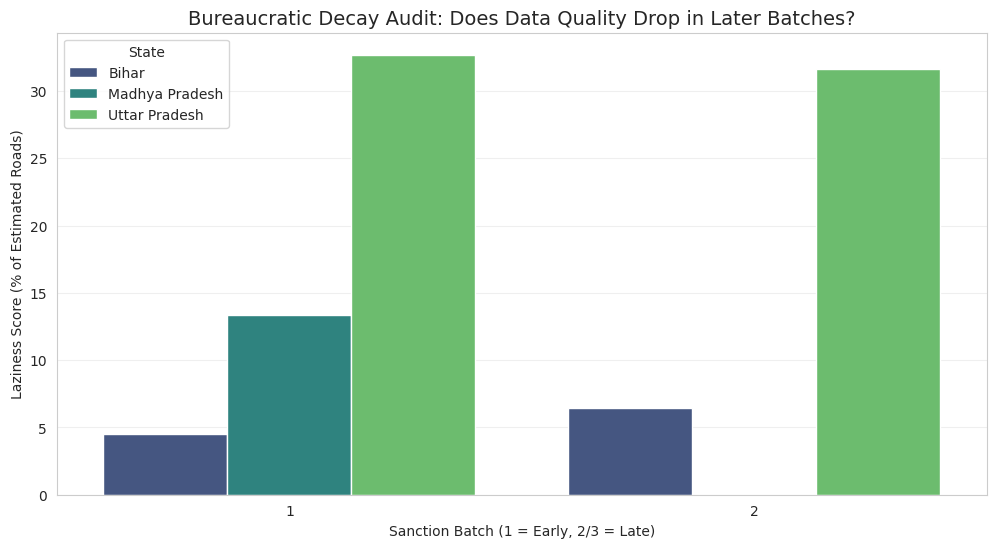

📉 BATCH-WISE INTEGRITY REPORT
State_Name  Bihar  Madhya Pradesh  Uttar Pradesh
IMS_BATCH                                       
1             4.5            13.4           32.7
2             6.4             NaN           31.6


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# 2. Filter for Valid Roads (No Bridges, No Zero Lengths)
df_batch = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# 3. Create the Forensic Flag (.0 or .5 integers)
df_batch['Is_Lazy'] = df_batch['PROPOSED_L'].apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5))

# 4. Group by State and Batch
batch_audit = df_batch.groupby(['State_Name', 'IMS_BATCH']).agg(
    Total_Projects=('PROPOSED_L', 'count'),
    Lazy_Count=('Is_Lazy', 'sum')
).reset_index()

# 5. Calculate Laziness Percentage
batch_audit['Laziness_Score'] = (batch_audit['Lazy_Count'] / batch_audit['Total_Projects']) * 100

# Filter out tiny batches (noise)
batch_audit = batch_audit[batch_audit['Total_Projects'] > 20]

# 6. Visualize: The "Panic Decay" Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=batch_audit,
    x='IMS_BATCH',
    y='Laziness_Score',
    hue='State_Name',
    palette='viridis'
)

plt.title("Bureaucratic Decay Audit: Does Data Quality Drop in Later Batches?", fontsize=14)
plt.ylabel("Laziness Score (% of Estimated Roads)")
plt.xlabel("Sanction Batch (1 = Early, 2/3 = Late)")
plt.legend(title='State')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print the Hard Numbers for your Ledger
print("="*60)
print("📉 BATCH-WISE INTEGRITY REPORT")
print("="*60)
print(batch_audit.pivot(index='IMS_BATCH', columns='State_Name', values='Laziness_Score').round(1))


/tmp/ipykernel_1605/3698568392.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_zombies, x='Unique_Years', y='Label', palette='magma', ax=ax3, orient='h')


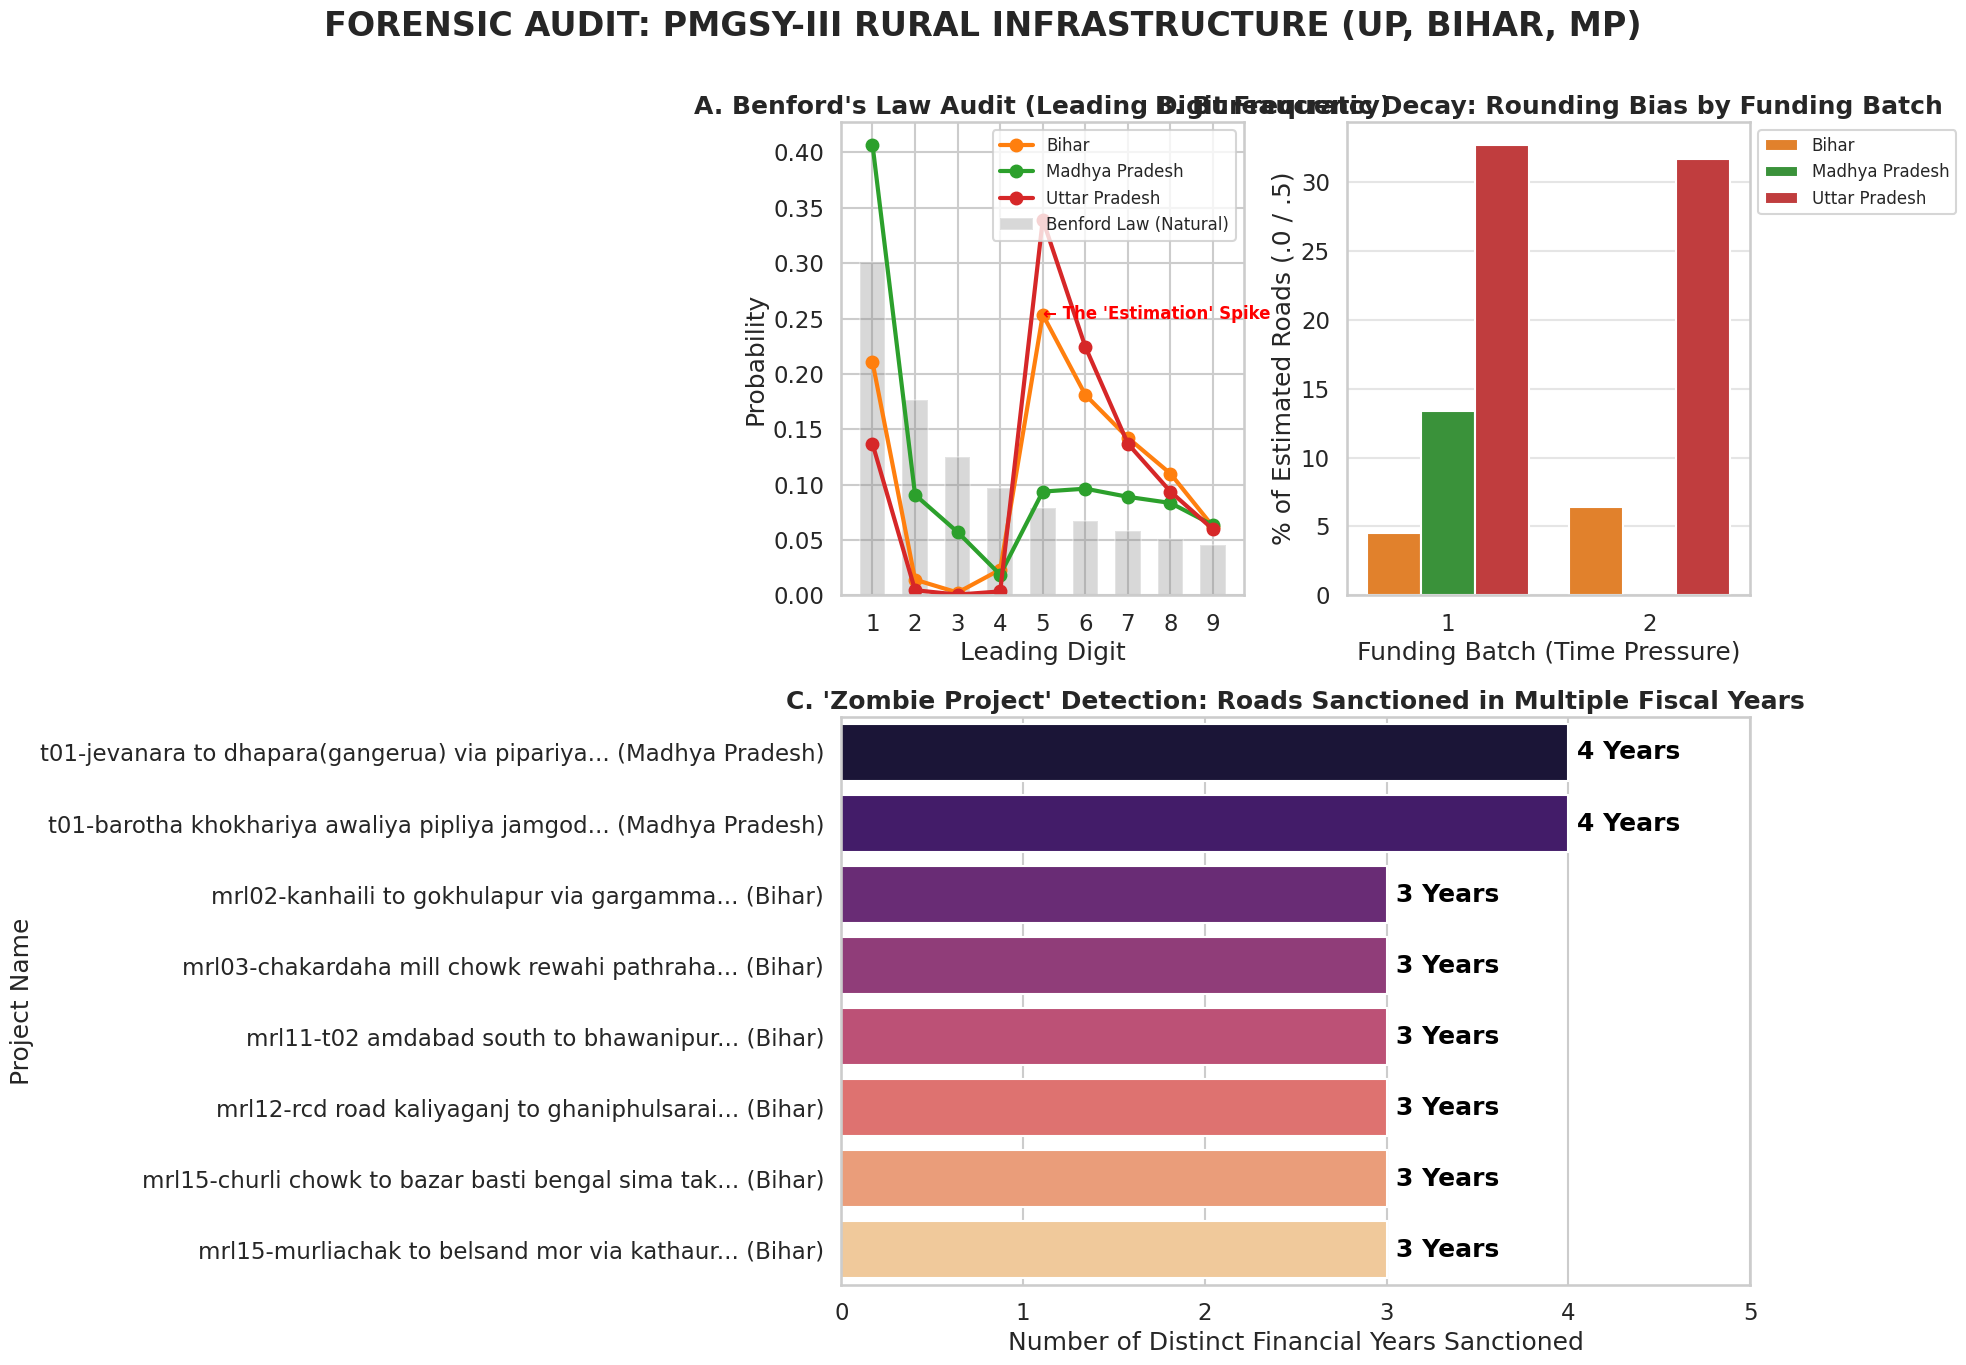

✅ REPORT GENERATED: PMGSY_Forensic_Report.png
This image contains the 3-point forensic evidence for your submission.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Setup & Data Loading
sns.set_theme(style="whitegrid", context="talk") # Professional "Talk" context for readable fonts
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")

# Clean numeric columns immediately
df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
df = df.dropna(subset=['PROPOSED_L'])

# Initialize the Report Grid (2 Rows, 2 Columns - Bottom row spans full width)
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2]) # Bottom chart slightly taller

# ==============================================================================
# 📉 SLOT 1 (Top Left): BENFORD'S LAW (The "Fraud" Detector)
# ==============================================================================
ax1 = fig.add_subplot(gs[0, 0])

# Filter Valid Roads (No Bridges)
df_benford = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# Extract Leading Digit
def get_leading_digit(x):
    s = str(float(x))
    for char in s:
        if char in '123456789': return int(char)
    return np.nan

df_benford['First_Digit'] = df_benford['PROPOSED_L'].apply(get_leading_digit)
benford_digits = list(range(1, 10))
benford_probs = [math.log10(1 + 1/d) for d in benford_digits]

# Plot Lines per State
colors = {'Uttar Pradesh': '#d62728', 'Bihar': '#ff7f0e', 'Madhya Pradesh': '#2ca02c'} # Red/Orange/Green
for state in df_benford['State_Name'].unique():
    state_data = df_benford[df_benford['State_Name'] == state]
    counts = state_data['First_Digit'].value_counts(normalize=True).sort_index()
    # Reindex to ensure 1-9
    counts = counts.reindex(benford_digits, fill_value=0)
    ax1.plot(counts.index, counts.values, marker='o', linewidth=3, label=state, color=colors.get(state, 'gray'))

# Plot Theoretical Benford Bars
ax1.bar(benford_digits, benford_probs, color='gray', alpha=0.3, label='Benford Law (Natural)', width=0.6)

ax1.set_title("A. Benford's Law Audit (Leading Digit Frequency)", fontweight='bold')
ax1.set_xlabel("Leading Digit")
ax1.set_ylabel("Probability")
ax1.set_xticks(benford_digits)
ax1.legend(fontsize=12)
ax1.text(5, 0.25, "← The 'Estimation' Spike", color='red', fontsize=12, fontweight='bold')


# ==============================================================================
# 📉 SLOT 2 (Top Right): BATCH DECAY (The "Bureaucracy" Check)
# ==============================================================================
ax2 = fig.add_subplot(gs[0, 1])

# Filter & Tag "Lazy" Roads (.0 or .5)
df_batch = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()
df_batch['Is_Lazy'] = df_batch['PROPOSED_L'].apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5))

# Group by Batch
batch_data = df_batch.groupby(['State_Name', 'IMS_BATCH']).agg(
    Total=('PROPOSED_L', 'count'), Lazy=('Is_Lazy', 'sum')
).reset_index()
batch_data['Laziness_Pct'] = (batch_data['Lazy'] / batch_data['Total']) * 100
batch_data = batch_data[batch_data['Total'] > 20] # Filter noise

sns.barplot(data=batch_data, x='IMS_BATCH', y='Laziness_Pct', hue='State_Name', palette=colors, ax=ax2)

ax2.set_title("B. Bureaucratic Decay: Rounding Bias by Funding Batch", fontweight='bold')
ax2.set_ylabel("% of Estimated Roads (.0 / .5)")
ax2.set_xlabel("Funding Batch (Time Pressure)")
ax2.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
ax2.grid(axis='y', alpha=0.5)


# ==============================================================================
# 🧟 SLOT 3 (Bottom Full): ZOMBIE PROJECTS (The "Fiscal Churn")
# ==============================================================================
ax3 = fig.add_subplot(gs[1, :])

# Identify Recycled Names
df['Clean_Name'] = df['WORK_NAME'].str.lower().str.strip()
zombies = df.groupby(['State_Name', 'Clean_Name']).agg(
    Unique_Years=('IMS_YEAR', 'nunique'),
    Years_List=('IMS_YEAR', 'unique')
).reset_index()

top_zombies = zombies[zombies['Unique_Years'] > 2].sort_values(by='Unique_Years', ascending=False).head(8)

# Create Label for Plot (Name + State)
top_zombies['Label'] = top_zombies['Clean_Name'].str[:50] + "... (" + top_zombies['State_Name'] + ")"

sns.barplot(data=top_zombies, x='Unique_Years', y='Label', palette='magma', ax=ax3, orient='h')

ax3.set_title("C. 'Zombie Project' Detection: Roads Sanctioned in Multiple Fiscal Years", fontweight='bold')
ax3.set_xlabel("Number of Distinct Financial Years Sanctioned")
ax3.set_ylabel("Project Name")
ax3.set_xlim(0, 5)

# Annotate Bars
for i, v in enumerate(top_zombies['Unique_Years']):
    ax3.text(v + 0.05, i, f"{v} Years", color='black', va='center', fontweight='bold')

# ==============================================================================
# 🏁 FINALIZE & SAVE
# ==============================================================================
plt.suptitle("FORENSIC AUDIT: PMGSY-III RURAL INFRASTRUCTURE (UP, BIHAR, MP)", fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Make room for main title

# Save to Colab
plt.savefig("PMGSY_Forensic_Report.png", dpi=300, bbox_inches='tight')
plt.show()

print("="*60)
print("✅ REPORT GENERATED: PMGSY_Forensic_Report.png")
print("This image contains the 3-point forensic evidence for your submission.")
print("="*60)


/tmp/ipykernel_1605/777373415.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_zombies, x='Unique_Years', y='Label', palette='magma', ax=ax3, orient='h')


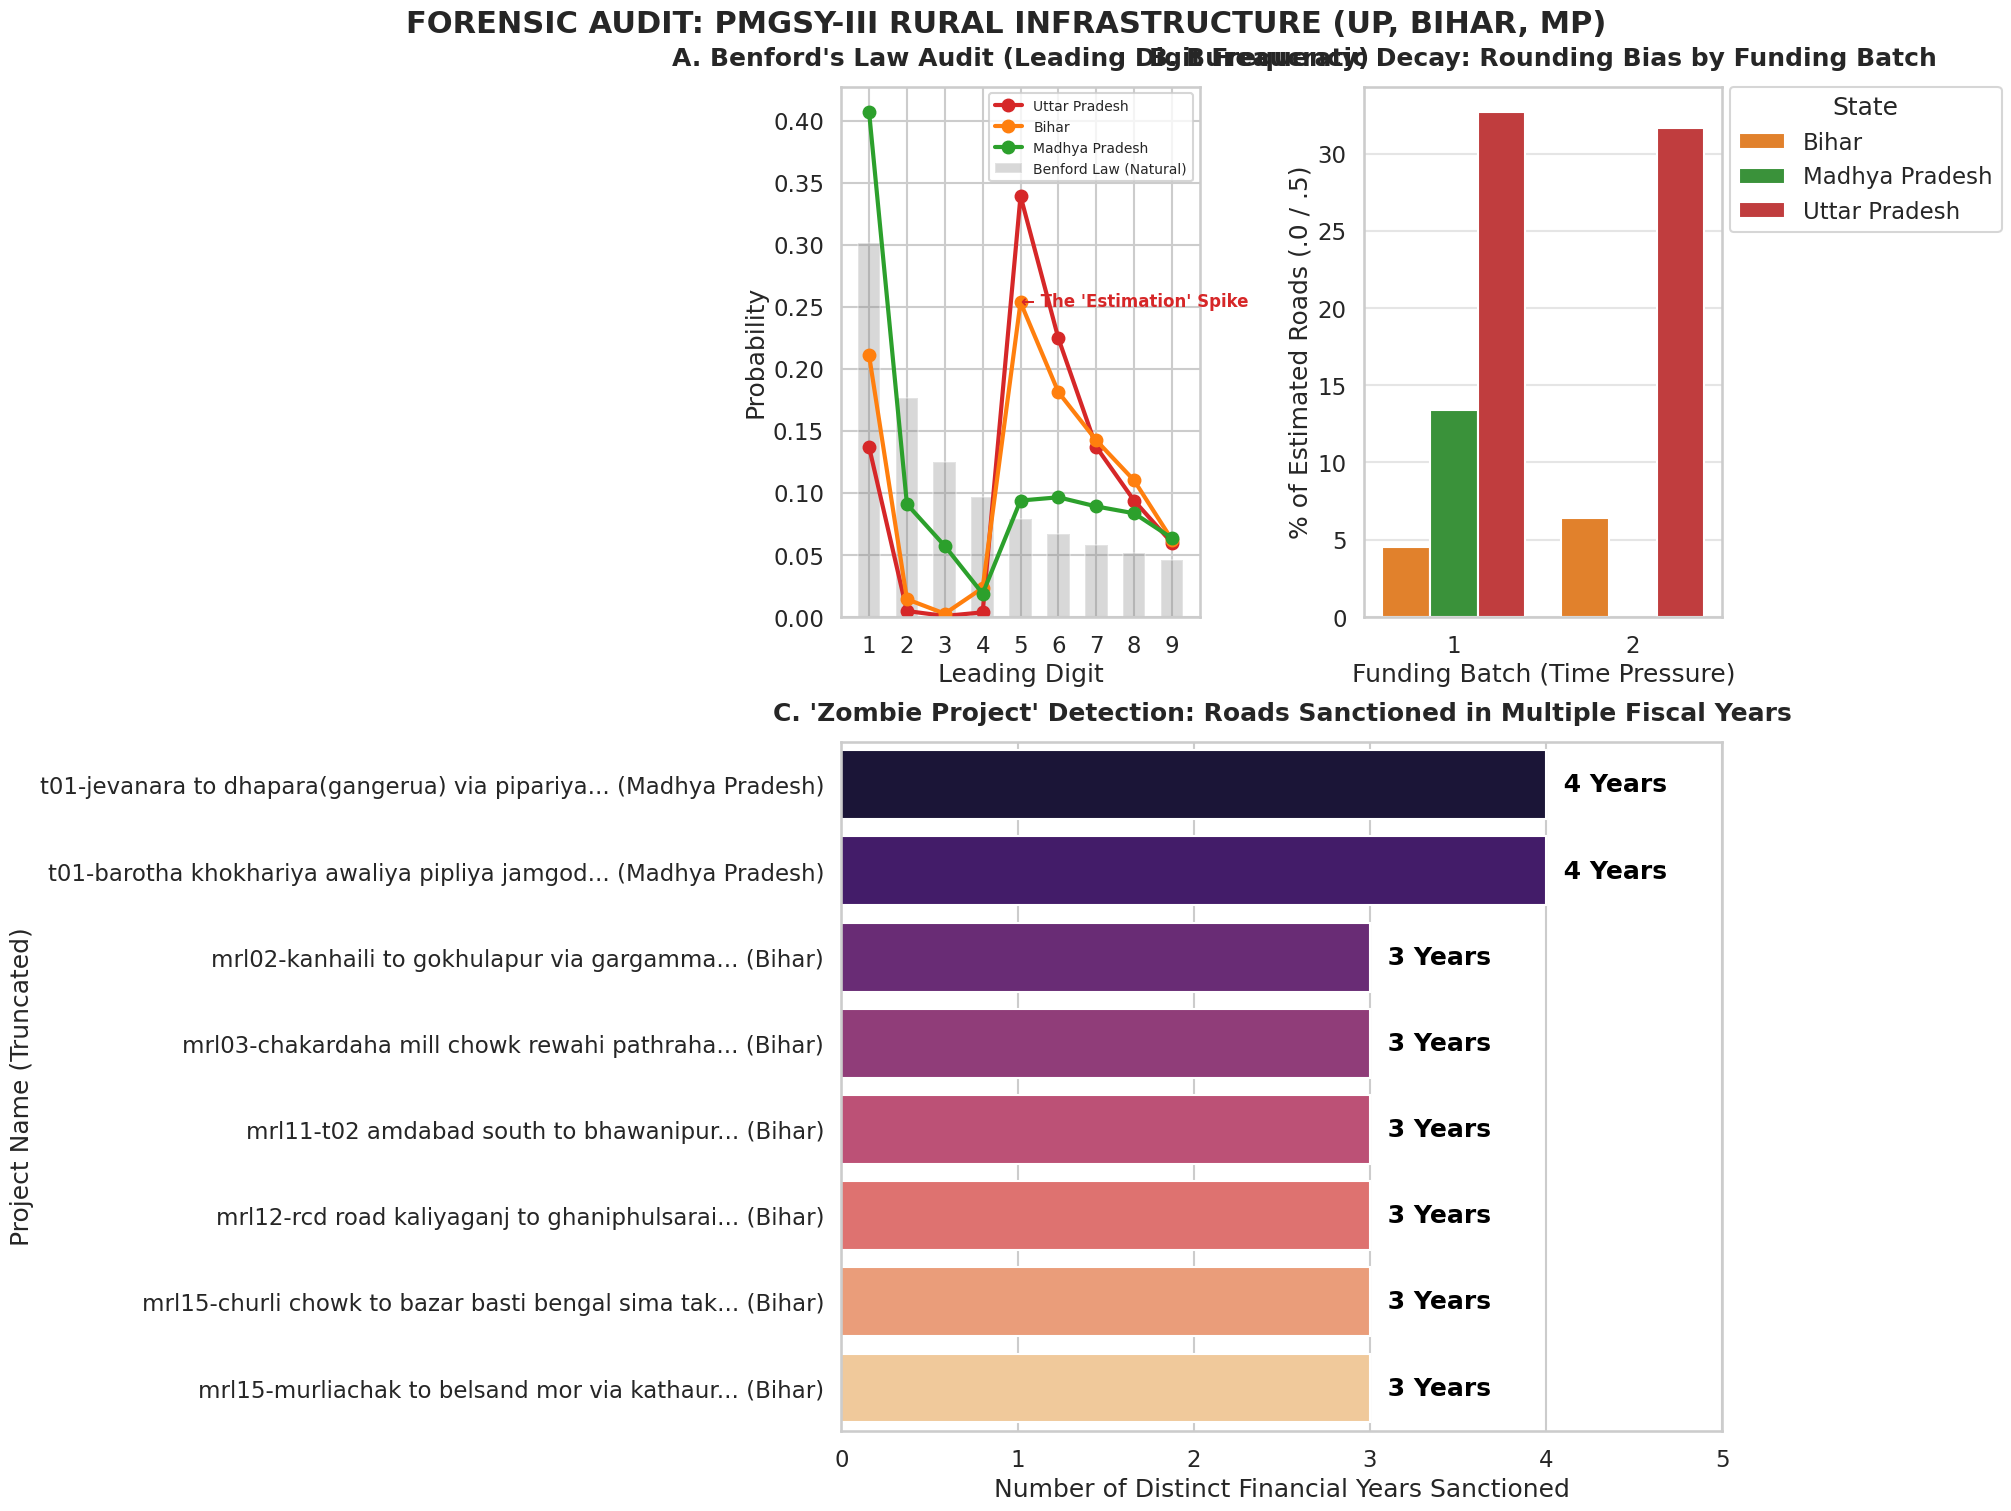

✅ FIXED REPORT GENERATED: PMGSY_Forensic_Report_Fixed.png
Layout is now 'Constrained' - No titles or legends should overlap.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Setup & Data Loading
# "constrained" layout is the secret to fixing overlaps automatically
sns.set_theme(style="whitegrid", context="talk")
fig = plt.figure(figsize=(20, 15), layout="constrained")

# Load Data
df = pd.read_csv("PMGSY_Master_Dataset_Combined.csv")
df['PROPOSED_L'] = pd.to_numeric(df['PROPOSED_L'], errors='coerce')
df = df.dropna(subset=['PROPOSED_L'])

# Define Grid: Bottom row is slightly taller (height_ratios=[1, 1.3])
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3])

# ==============================================================================
# 📉 SLOT 1 (Top Left): BENFORD'S LAW (The "Fraud" Detector)
# ==============================================================================
ax1 = fig.add_subplot(gs[0, 0])

# Filter Valid Roads
df_benford = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()

# Helper to get leading digit
def get_leading_digit(x):
    s = str(float(x))
    for char in s:
        if char in '123456789': return int(char)
    return np.nan

df_benford['First_Digit'] = df_benford['PROPOSED_L'].apply(get_leading_digit)
benford_digits = list(range(1, 10))
benford_probs = [math.log10(1 + 1/d) for d in benford_digits]

# Colors for consistency
colors = {'Uttar Pradesh': '#d62728', 'Bihar': '#ff7f0e', 'Madhya Pradesh': '#2ca02c'}

# Plot State Lines
for state in ['Uttar Pradesh', 'Bihar', 'Madhya Pradesh']:
    if state in df_benford['State_Name'].unique():
        state_data = df_benford[df_benford['State_Name'] == state]
        counts = state_data['First_Digit'].value_counts(normalize=True).sort_index()
        counts = counts.reindex(benford_digits, fill_value=0)
        ax1.plot(counts.index, counts.values, marker='o', linewidth=3, label=state, color=colors[state])

# Plot Theoretical Benford Bars
ax1.bar(benford_digits, benford_probs, color='gray', alpha=0.3, label='Benford Law (Natural)', width=0.6)

ax1.set_title("A. Benford's Law Audit (Leading Digit Frequency)", fontweight='bold', pad=15)
ax1.set_xlabel("Leading Digit")
ax1.set_ylabel("Probability")
ax1.set_xticks(benford_digits)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.text(5, 0.25, "← The 'Estimation' Spike", color='#d62728', fontsize=12, fontweight='bold', ha='left')


# ==============================================================================
# 📉 SLOT 2 (Top Right): BATCH DECAY (The "Bureaucracy" Check)
# ==============================================================================
ax2 = fig.add_subplot(gs[0, 1])

# Filter & Tag "Lazy" Roads
df_batch = df[(df['PROPOSED_L'] > 0) & (df['Proposal_T'] != 'L')].copy()
df_batch['Is_Lazy'] = df_batch['PROPOSED_L'].apply(lambda x: (x % 1 == 0) or (x % 1 == 0.5))

# Group by Batch
batch_data = df_batch.groupby(['State_Name', 'IMS_BATCH']).agg(
    Total=('PROPOSED_L', 'count'), Lazy=('Is_Lazy', 'sum')
).reset_index()
batch_data['Laziness_Pct'] = (batch_data['Lazy'] / batch_data['Total']) * 100
batch_data = batch_data[batch_data['Total'] > 20] # Filter noise

sns.barplot(data=batch_data, x='IMS_BATCH', y='Laziness_Pct', hue='State_Name', palette=colors, ax=ax2)

ax2.set_title("B. Bureaucratic Decay: Rounding Bias by Funding Batch", fontweight='bold', pad=15)
ax2.set_ylabel("% of Estimated Roads (.0 / .5)")
ax2.set_xlabel("Funding Batch (Time Pressure)")
# Move legend OUTSIDE the plot to prevent overlapping
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='State')
ax2.grid(axis='y', alpha=0.5)


# ==============================================================================
# 🧟 SLOT 3 (Bottom Full): ZOMBIE PROJECTS (The "Fiscal Churn")
# ==============================================================================
ax3 = fig.add_subplot(gs[1, :])

# Identify Recycled Names
df['Clean_Name'] = df['WORK_NAME'].str.lower().str.strip()
zombies = df.groupby(['State_Name', 'Clean_Name']).agg(
    Unique_Years=('IMS_YEAR', 'nunique'),
    Years_List=('IMS_YEAR', 'unique')
).reset_index()

top_zombies = zombies[zombies['Unique_Years'] > 2].sort_values(by='Unique_Years', ascending=False).head(8)

# Truncate long names for display (First 60 chars + State)
top_zombies['Label'] = top_zombies['Clean_Name'].str[:60] + "... (" + top_zombies['State_Name'] + ")"

sns.barplot(data=top_zombies, x='Unique_Years', y='Label', palette='magma', ax=ax3, orient='h')

ax3.set_title("C. 'Zombie Project' Detection: Roads Sanctioned in Multiple Fiscal Years", fontweight='bold', pad=15)
ax3.set_xlabel("Number of Distinct Financial Years Sanctioned")
ax3.set_ylabel("Project Name (Truncated)")
ax3.set_xlim(0, 5)

# Annotate Bars inside
for i, v in enumerate(top_zombies['Unique_Years']):
    ax3.text(v + 0.05, i, f" {v} Years", color='black', va='center', fontweight='bold')

# ==============================================================================
# 🏁 SAVE
# ==============================================================================
fig.suptitle("FORENSIC AUDIT: PMGSY-III RURAL INFRASTRUCTURE (UP, BIHAR, MP)", fontsize=22, fontweight='bold')

# Save to Colab
plt.savefig("PMGSY_Forensic_Report_Fixed.png", dpi=300)
plt.show()

print("="*60)
print("✅ FIXED REPORT GENERATED: PMGSY_Forensic_Report_Fixed.png")
print("Layout is now 'Constrained' - No titles or legends should overlap.")
print("="*60)


In [ ]:
from google.colab import files

# 1. Save the dataframe to a CSV file in the virtual machine
df.to_csv('PMGSY_Master_Dataset_Combined.csv', index=False)

# 2. Trigger the browser download
files.download('PMGSY_Master_Dataset_Combined.csv')


NameError: name 'df' is not defined

Loaded Rajasthan: 1731 rows
Loaded Maharashtra: 1677 rows
Loaded Odisha: 2540 rows

DATASET COMPATIBILITY AUDIT

1. BASIC DATA QUALITY
------------------------------------------------------------------------------------------
      Dataset  Rows  Exact_Duplicates  Exact_Dup_%  ID_Null  Unique_IDs  Duplicate_ID_Rows
CORE_BH_UP_MP  8868              3001        33.84        0        5867               3001
    Rajasthan  1731               774        44.71        0         957                774
  Maharashtra  1677               411        24.51        0        1266                411
       Odisha  2540               996        39.21        0        1544                996

2. SCHEMA + DATA TYPE COMPARISON
------------------------------------------------------------------------------------------

Rajasthan
Missing columns: ['STATE_NAME']
Extra columns:   None

Dtype differences:
  None

Maharashtra
Missing columns: ['STATE_NAME']
Extra columns:   None

Dtype differences:
  None

Odisha


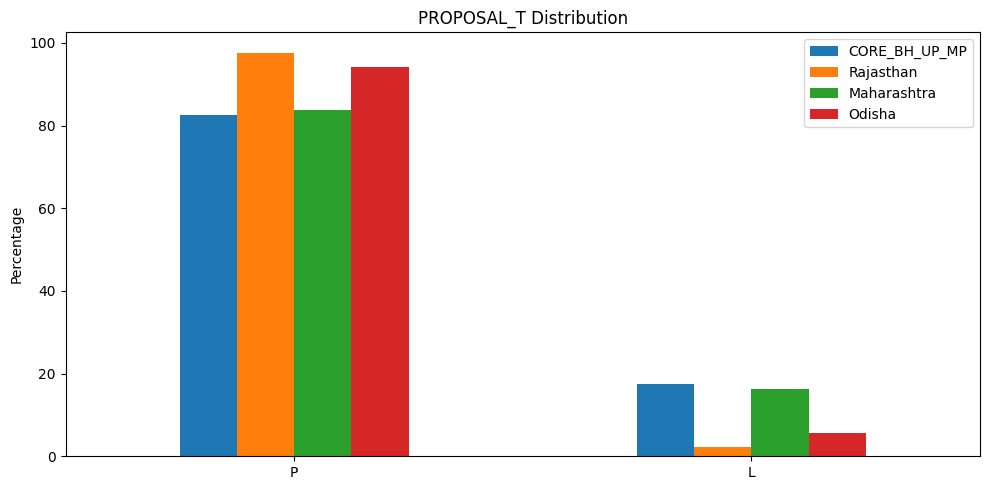


5. NUMERIC DISTRIBUTION
------------------------------------------------------------------------------------------

--- PROPOSED_L ---
      Dataset  Count  Mean  Median   Std    Q1    Q3  Min   Max
CORE_BH_UP_MP   8868 8.648    7.15 7.242 5.200 11.15  0.0 45.16
    Rajasthan   1731 9.917    8.50 5.646 6.000 12.20  0.0 49.00
  Maharashtra   1677 5.672    5.50 3.676 3.730  7.50  0.0 28.22
       Odisha   2540 6.509    6.00 3.450 4.508  7.90  0.0 32.42

KS statistic vs CORE:
Rajasthan       KS=0.164 p=2.451e-34
Maharashtra     KS=0.224 p=1.739e-62
Odisha          KS=0.189 p=6.314e-62

--- IMS_YEAR ---
      Dataset  Count     Mean  Median   Std     Q1     Q3  Min  Max
CORE_BH_UP_MP   8868 2020.964  2021.0 1.048 2020.0 2022.0 2019 2024
    Rajasthan   1731 2020.694  2020.0 1.286 2020.0 2022.0 2019 2024
  Maharashtra   1677 2021.742  2022.0 1.571 2020.0 2023.0 2020 2026
       Odisha   2540 2020.553  2021.0 0.541 2020.0 2021.0 2020 2022

KS statistic vs CORE:
Rajasthan       KS=0.221 p=9.

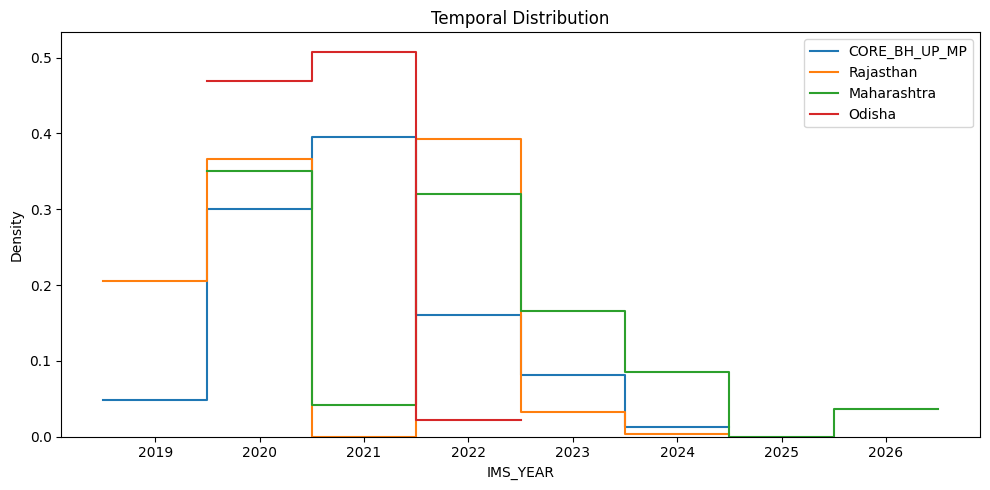

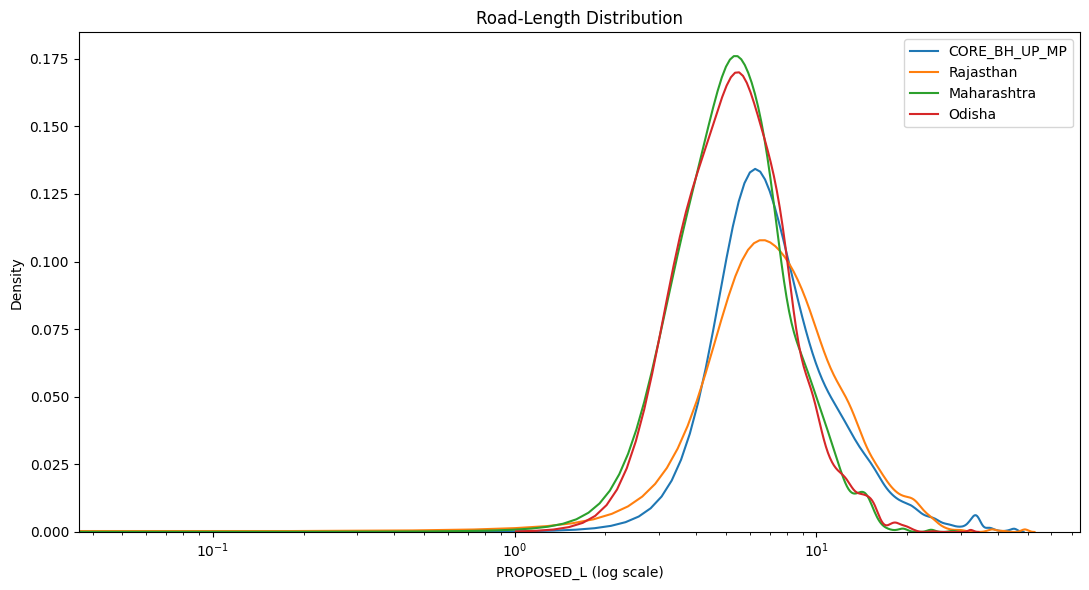


AUDIT COMPLETE


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

# ============================================================
# CONFIGURATION
# ============================================================

master_file = "PMGSY_Master_Dataset_Combined(1).csv"

candidate_files = {
    "Rajasthan": "Proposal_PMGSY-III_RAJASTHAN.shp",
    "Maharashtra": "Proposal_PMGSY-III_MAHARASHTRA.shp",
    "Odisha": "Proposal_PMGSY-III_ODISHA.shp"
}

ID_COL = "MRL_ID"

NUMERIC_COLS = [
    "PROPOSED_L",
    "IMS_YEAR"
]

CATEGORICAL_COLS = [
    "PROPOSAL_T",
    "CN_CODE"
]

# ============================================================
# LOADERS
# ============================================================

def load_dataset(filename, dataset_name):
    if filename.lower().endswith(".shp"):
        gdf = gpd.read_file(filename)
        df = pd.DataFrame(gdf.drop(columns="geometry", errors="ignore"))
    else:
        df = pd.read_csv(filename)

    df.columns = df.columns.str.upper().str.strip()
    df["DATASET"] = dataset_name

    return df


# Core dataset
core = load_dataset(master_file, "CORE_BH_UP_MP")

datasets = {
    "CORE_BH_UP_MP": core
}

# Candidates
for state, filename in candidate_files.items():
    try:
        datasets[state] = load_dataset(filename, state)
        print(f"Loaded {state}: {len(datasets[state])} rows")
    except Exception as e:
        print(f"FAILED {state}: {e}")

print("\n" + "=" * 90)
print("DATASET COMPATIBILITY AUDIT")
print("=" * 90)


# ============================================================
# 1. SIZE + EXACT DUPLICATES + ID UNIQUENESS
# ============================================================

print("\n1. BASIC DATA QUALITY")
print("-" * 90)

basic_report = []

for name, df in datasets.items():

    exact_dupes = df.duplicated().sum()

    if ID_COL in df.columns:
        id_null = df[ID_COL].isna().sum()
        id_unique = df[ID_COL].nunique(dropna=True)
        id_duplicate_rows = df[ID_COL].duplicated().sum()
    else:
        id_null = np.nan
        id_unique = np.nan
        id_duplicate_rows = np.nan

    basic_report.append({
        "Dataset": name,
        "Rows": len(df),
        "Exact_Duplicates": exact_dupes,
        "Exact_Dup_%": round(exact_dupes / len(df) * 100, 2),
        "ID_Null": id_null,
        "Unique_IDs": id_unique,
        "Duplicate_ID_Rows": id_duplicate_rows
    })

basic_report = pd.DataFrame(basic_report)

print(basic_report.to_string(index=False))


# ============================================================
# 2. SCHEMA + DTYPE COMPARISON
# ============================================================

print("\n2. SCHEMA + DATA TYPE COMPARISON")
print("-" * 90)

core_cols = set(core.columns)

for name, df in datasets.items():

    if name == "CORE_BH_UP_MP":
        continue

    cand_cols = set(df.columns)

    missing = sorted(core_cols - cand_cols)
    extra = sorted(cand_cols - core_cols)

    print(f"\n{name}")
    print(f"Missing columns: {missing if missing else 'None'}")
    print(f"Extra columns:   {extra if extra else 'None'}")

    print("\nDtype differences:")

    common_cols = sorted(core_cols & cand_cols)

    dtype_diffs = []

    for col in common_cols:
        core_type = str(core[col].dtype)
        cand_type = str(df[col].dtype)

        if core_type != cand_type:
            dtype_diffs.append(
                (col, core_type, cand_type)
            )

    if dtype_diffs:
        for row in dtype_diffs:
            print(f"  {row[0]} : CORE={row[1]} | {name}={row[2]}")
    else:
        print("  None")


# ============================================================
# 3. MISSINGNESS COMPARISON
# ============================================================

print("\n3. MISSINGNESS")
print("-" * 90)

common_cols = sorted(
    set(core.columns).intersection(
        *[set(df.columns) for name, df in datasets.items()]
    )
)

missingness = {}

for col in common_cols:
    missingness[col] = {
        name: round(df[col].isna().mean() * 100, 2)
        for name, df in datasets.items()
    }

missingness_df = pd.DataFrame(missingness).T

print(missingness_df.to_string())


# ============================================================
# 4. PROPOSAL TYPE DISTRIBUTION
# ============================================================

print("\n4. PROPOSAL_T DISTRIBUTION")
print("-" * 90)

if "PROPOSAL_T" in common_cols:

    proposal_dist = pd.DataFrame()

    for name, df in datasets.items():
        dist = (
            df["PROPOSAL_T"]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
            .rename(name)
        )

        proposal_dist = pd.concat(
            [proposal_dist, dist],
            axis=1
        )

    print(proposal_dist.round(2).to_string())

    proposal_dist.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.ylabel("Percentage")
    plt.title("PROPOSAL_T Distribution")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. NUMERIC DISTRIBUTION
# ============================================================

print("\n5. NUMERIC DISTRIBUTION")
print("-" * 90)

for col in NUMERIC_COLS:

    if col not in common_cols:
        print(f"{col}: not present in all datasets")
        continue

    print(f"\n--- {col} ---")

    stats = []

    for name, df in datasets.items():

        x = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna()

        stats.append({
            "Dataset": name,
            "Count": len(x),
            "Mean": x.mean(),
            "Median": x.median(),
            "Std": x.std(),
            "Q1": x.quantile(0.25),
            "Q3": x.quantile(0.75),
            "Min": x.min(),
            "Max": x.max()
        })

    stats_df = pd.DataFrame(stats)

    print(stats_df.round(3).to_string(index=False))

    # -----------------------------
    # KS comparison against CORE
    # -----------------------------

    core_values = pd.to_numeric(
        core[col],
        errors="coerce"
    ).dropna()

    print("\nKS statistic vs CORE:")

    for name, df in datasets.items():

        if name == "CORE_BH_UP_MP":
            continue

        cand_values = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna()

        if len(cand_values) > 0:

            ks_stat, p_value = ks_2samp(
                core_values,
                cand_values
            )

            print(
                f"{name:15s} "
                f"KS={ks_stat:.3f} "
                f"p={p_value:.4g}"
            )


# ============================================================
# 6. CATEGORICAL DISTRIBUTION COMPARISON
# ============================================================

def js_divergence(p, q):

    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)

    def kl(a, b):
        mask = a > 0
        return np.sum(
            a[mask] * np.log2(a[mask] / b[mask])
        )

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


print("\n6. CATEGORICAL DISTRIBUTION DIFFERENCE")
print("-" * 90)

for col in CATEGORICAL_COLS:

    if col not in common_cols:
        print(f"{col}: not present in all datasets")
        continue

    print(f"\n--- {col} ---")

    core_counts = core[col].fillna("<NA>").value_counts()

    for name, df in datasets.items():

        if name == "CORE_BH_UP_MP":
            continue

        cand_counts = df[col].fillna("<NA>").value_counts()

        categories = set(core_counts.index) | set(cand_counts.index)

        p = np.array([
            core_counts.get(x, 0)
            for x in categories
        ])

        q = np.array([
            cand_counts.get(x, 0)
            for x in categories
        ])

        js = js_divergence(p, q)

        print(
            f"{name:15s} "
            f"JS divergence = {js:.4f}"
        )


# ============================================================
# 7. TEMPORAL COVERAGE
# ============================================================

print("\n7. TEMPORAL COVERAGE")
print("-" * 90)

if "IMS_YEAR" in common_cols:

    for name, df in datasets.items():

        years = pd.to_numeric(
            df["IMS_YEAR"],
            errors="coerce"
        ).dropna()

        print(
            f"{name:15s}: "
            f"{years.min()} - {years.max()} "
            f"({years.nunique()} unique years)"
        )

    plt.figure(figsize=(10, 5))

    for name, df in datasets.items():

        years = pd.to_numeric(
            df["IMS_YEAR"],
            errors="coerce"
        ).dropna()

        sns.histplot(
            years,
            discrete=True,
            stat="density",
            element="step",
            fill=False,
            label=name
        )

    plt.title("Temporal Distribution")
    plt.xlabel("IMS_YEAR")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. PROPOSED_L DISTRIBUTION
# ============================================================

if "PROPOSED_L" in common_cols:

    plt.figure(figsize=(11, 6))

    for name, df in datasets.items():

        x = pd.to_numeric(
            df["PROPOSED_L"],
            errors="coerce"
        )

        x = x[x > 0]

        sns.kdeplot(
            x,
            label=name,
            common_norm=False
        )

    plt.xscale("log")
    plt.xlabel("PROPOSED_L (log scale)")
    plt.ylabel("Density")
    plt.title("Road-Length Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


print("\n" + "=" * 90)
print("AUDIT COMPLETE")
print("=" * 90)

In [2]:
# ============================================================
# STRATIFIED COMPATIBILITY AUDIT
# P vs P and L vs L
# Run AFTER the previous loading code
# ============================================================

from scipy.stats import ks_2samp
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. REMOVE EXACT DUPLICATES BEFORE COMPARISON
# ------------------------------------------------------------

cleaned = {}

print("=" * 95)
print("0. EXACT DUPLICATE REMOVAL")
print("=" * 95)

for name, df in datasets.items():

    before = len(df)
    df_clean = df.drop_duplicates().copy()
    after = len(df_clean)

    cleaned[name] = df_clean

    print(
        f"{name:15s} | "
        f"Before={before:5d} | "
        f"Removed={before-after:5d} | "
        f"Unique={after:5d}"
    )


# ------------------------------------------------------------
# 1. STRATUM COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("1. P / L STRATUM COUNTS AFTER DEDUPLICATION")
print("=" * 95)

stratum_rows = []

for name, df in cleaned.items():

    for proposal_type in ["P", "L"]:

        subset = df[df["PROPOSAL_T"] == proposal_type]

        stratum_rows.append({
            "Dataset": name,
            "Type": proposal_type,
            "Rows": len(subset),
            "Percentage": round(
                len(subset) / len(df) * 100, 2
            )
        })

stratum_report = pd.DataFrame(stratum_rows)

print(
    stratum_report.to_string(index=False)
)


# ------------------------------------------------------------
# 2. COLUMN / DTYPE COMPATIBILITY
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("2. SCHEMA COMPATIBILITY")
print("=" * 95)

core_clean = cleaned["CORE_BH_UP_MP"]

core_cols = set(core_clean.columns)

for name, df in cleaned.items():

    if name == "CORE_BH_UP_MP":
        continue

    print(f"\n{name}")

    candidate_cols = set(df.columns)

    print(
        "Missing from candidate:",
        sorted(core_cols - candidate_cols)
        if core_cols - candidate_cols else "None"
    )

    print(
        "Extra in candidate:",
        sorted(candidate_cols - core_cols)
        if candidate_cols - core_cols else "None"
    )

    dtype_changes = []

    for col in sorted(core_cols & candidate_cols):

        core_type = str(core_clean[col].dtype)
        cand_type = str(df[col].dtype)

        if core_type != cand_type:
            dtype_changes.append(
                f"{col}: CORE={core_type}, {name}={cand_type}"
            )

    print("Dtype differences:")
    print(dtype_changes if dtype_changes else "None")


# ------------------------------------------------------------
# 3. MISSINGNESS: P vs P AND L vs L
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("3. MISSINGNESS DIFFERENCE BY STRATUM")
print("=" * 95)

for proposal_type in ["P", "L"]:

    print(f"\n--- {proposal_type} RECORDS ---")

    for name, df in cleaned.items():

        subset = df[
            df["PROPOSAL_T"] == proposal_type
        ]

        missing = (
            subset
            .isna()
            .mean()
            .mul(100)
            .round(2)
        )

        print(f"\n{name}")
        print(missing.to_string())


# ------------------------------------------------------------
# 4. NUMERIC DISTRIBUTION COMPARISON
# ------------------------------------------------------------

numeric_candidates = [
    "PROPOSED_L",
    "IMS_YEAR"
]

print("\n" + "=" * 95)
print("4. NUMERIC DISTRIBUTION: CORE vs CANDIDATE")
print("=" * 95)

numeric_results = []

for proposal_type in ["P", "L"]:

    print(f"\n{'-'*20} {proposal_type} RECORDS {'-'*20}")

    core_subset = core_clean[
        core_clean["PROPOSAL_T"] == proposal_type
    ]

    for col in numeric_candidates:

        if col not in core_subset.columns:
            continue

        core_values = pd.to_numeric(
            core_subset[col],
            errors="coerce"
        ).dropna()

        # Skip constant variables
        if core_values.nunique() <= 1:
            print(
                f"{col}: CORE is constant for {proposal_type}; "
                "distribution comparison skipped."
            )
            continue

        for name, df in cleaned.items():

            if name == "CORE_BH_UP_MP":
                continue

            cand_subset = df[
                df["PROPOSAL_T"] == proposal_type
            ]

            if col not in cand_subset.columns:
                continue

            cand_values = pd.to_numeric(
                cand_subset[col],
                errors="coerce"
            ).dropna()

            if len(cand_values) == 0:
                continue

            ks_stat, p_value = ks_2samp(
                core_values,
                cand_values
            )

            result = {
                "Type": proposal_type,
                "Feature": col,
                "Candidate": name,
                "Core_Median": core_values.median(),
                "Candidate_Median": cand_values.median(),
                "Core_IQR": (
                    core_values.quantile(0.75)
                    - core_values.quantile(0.25)
                ),
                "Candidate_IQR": (
                    cand_values.quantile(0.75)
                    - cand_values.quantile(0.25)
                ),
                "KS": round(ks_stat, 4),
                "p_value": p_value
            }

            numeric_results.append(result)

            print(
                f"{col:12s} | "
                f"{name:12s} | "
                f"Median CORE={core_values.median():.3f} | "
                f"Median CAND={cand_values.median():.3f} | "
                f"KS={ks_stat:.3f}"
            )

numeric_results = pd.DataFrame(numeric_results)


# ------------------------------------------------------------
# 5. CATEGORICAL DISTRIBUTION COMPARISON
# ------------------------------------------------------------

def js_divergence(p, q):

    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if p.sum() == 0 or q.sum() == 0:
        return np.nan

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)

    def kl(a, b):

        mask = a > 0

        return np.sum(
            a[mask] * np.log2(
                a[mask] / b[mask]
            )
        )

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


categorical_candidates = [
    "CN_CODE"
]

print("\n" + "=" * 95)
print("5. CATEGORICAL DISTRIBUTION DIFFERENCE")
print("=" * 95)

categorical_results = []

for proposal_type in ["P", "L"]:

    print(f"\n{'-'*20} {proposal_type} RECORDS {'-'*20}")

    core_subset = core_clean[
        core_clean["PROPOSAL_T"] == proposal_type
    ]

    for col in categorical_candidates:

        if col not in core_subset.columns:
            continue

        core_counts = (
            core_subset[col]
            .fillna("<NA>")
            .value_counts()
        )

        for name, df in cleaned.items():

            if name == "CORE_BH_UP_MP":
                continue

            cand_subset = df[
                df["PROPOSAL_T"] == proposal_type
            ]

            if col not in cand_subset.columns:
                continue

            cand_counts = (
                cand_subset[col]
                .fillna("<NA>")
                .value_counts()
            )

            categories = (
                set(core_counts.index)
                | set(cand_counts.index)
            )

            p = [
                core_counts.get(x, 0)
                for x in categories
            ]

            q = [
                cand_counts.get(x, 0)
                for x in categories
            ]

            js = js_divergence(p, q)

            categorical_results.append({
                "Type": proposal_type,
                "Feature": col,
                "Candidate": name,
                "JS_Divergence": round(js, 4)
            })

            print(
                f"{col:12s} | "
                f"{name:12s} | "
                f"JS={js:.4f}"
            )


# ------------------------------------------------------------
# 6. TEMPORAL OVERLAP
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("6. TEMPORAL COVERAGE BY STRATUM")
print("=" * 95)

for proposal_type in ["P", "L"]:

    print(f"\n--- {proposal_type} RECORDS ---")

    core_subset = core_clean[
        core_clean["PROPOSAL_T"] == proposal_type
    ]

    core_years = pd.to_numeric(
        core_subset["IMS_YEAR"],
        errors="coerce"
    ).dropna()

    core_year_set = set(core_years.astype(int))

    print(
        f"CORE: {sorted(core_year_set)}"
    )

    for name, df in cleaned.items():

        if name == "CORE_BH_UP_MP":
            continue

        subset = df[
            df["PROPOSAL_T"] == proposal_type
        ]

        years = pd.to_numeric(
            subset["IMS_YEAR"],
            errors="coerce"
        ).dropna()

        year_set = set(years.astype(int))

        overlap = sorted(
            core_year_set & year_set
        )

        only_candidate = sorted(
            year_set - core_year_set
        )

        print(
            f"{name:12s}: "
            f"{sorted(year_set)} | "
            f"Overlap={overlap} | "
            f"Candidate-only={only_candidate}"
        )


# ------------------------------------------------------------
# 7. IDENTIFY CANDIDATE FEATURE COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("7. POTENTIAL FEATURE / IDENTIFIER REVIEW")
print("=" * 95)

identifier_like = [
    "MRL_ID",
    "STATE_ID",
    "LGD_STATE",
    "LGD_DISTRI",
    "DISTRICT_I",
    "BLOCK_ID",
    "CN_CODE"
]

print(
    "\nColumns requiring justification before ML:"
)

for col in identifier_like:

    if col in core_clean.columns:
        print(f"  ⚠️ {col}")

print("\nOther common columns:")

for col in core_clean.columns:

    if col not in identifier_like + ["DATASET"]:
        print(f"  {col}")


# ------------------------------------------------------------
# 8. FINAL SUMMARY TABLE
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("8. NUMERIC COMPARISON SUMMARY")
print("=" * 95)

if not numeric_results.empty:

    summary = numeric_results[
        [
            "Type",
            "Feature",
            "Candidate",
            "Core_Median",
            "Candidate_Median",
            "Core_IQR",
            "Candidate_IQR",
            "KS"
        ]
    ]

    print(
        summary.to_string(index=False)
    )

print("\n" + "=" * 95)
print("AUDIT FINISHED")
print("=" * 95)

0. EXACT DUPLICATE REMOVAL
CORE_BH_UP_MP   | Before= 8868 | Removed= 3001 | Unique= 5867
Rajasthan       | Before= 1731 | Removed=  774 | Unique=  957
Maharashtra     | Before= 1677 | Removed=  411 | Unique= 1266
Odisha          | Before= 2540 | Removed=  996 | Unique= 1544

1. P / L STRATUM COUNTS AFTER DEDUPLICATION
      Dataset Type  Rows  Percentage
CORE_BH_UP_MP    P  4361       74.33
CORE_BH_UP_MP    L  1506       25.67
    Rajasthan    P   917       95.82
    Rajasthan    L    40        4.18
  Maharashtra    P   992       78.36
  Maharashtra    L   274       21.64
       Odisha    P  1400       90.67
       Odisha    L   144        9.33

2. SCHEMA COMPATIBILITY

Rajasthan
Missing from candidate: ['STATE_NAME']
Extra in candidate: None
Dtype differences:
None

Maharashtra
Missing from candidate: ['STATE_NAME']
Extra in candidate: None
Dtype differences:
None

Odisha
Missing from candidate: ['STATE_NAME']
Extra in candidate: None
Dtype differences:
None

3. MISSINGNESS DIFFERENCE

In [3]:
for name, df in cleaned.items():
    for ptype in ["P", "L"]:
        x = df[df["PROPOSAL_T"] == ptype]["CN_CODE"]
        print(
            name,
            ptype,
            "non-null =", x.notna().sum(),
            "unique =", x.nunique(dropna=True)
        )

CORE_BH_UP_MP P non-null = 4361 unique = 4361
CORE_BH_UP_MP L non-null = 0 unique = 0
Rajasthan P non-null = 917 unique = 917
Rajasthan L non-null = 0 unique = 0
Maharashtra P non-null = 992 unique = 992
Maharashtra L non-null = 0 unique = 0
Odisha P non-null = 1400 unique = 1400
Odisha L non-null = 0 unique = 0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# Compare CORE vs ADDITIONS, separately for P and L
# ---------------------------------------------------------

# Features that are candidates for the actual ML space
FEATURES = [
    "PROPOSED_L",
    "IMS_YEAR",
    "IMS_BATCH"
]

def adversarial_auc(proposal_type):

    frames = []

    for name, df in cleaned.items():

        x = df[df["PROPOSAL_T"] == proposal_type].copy()

        if len(x) == 0:
            continue

        x["DOMAIN"] = (
            0 if name == "CORE_BH_UP_MP" else 1
        )

        frames.append(x)

    data = pd.concat(frames, ignore_index=True)

    X = data[FEATURES].copy()
    y = data["DOMAIN"]

    numeric = ["PROPOSED_L", "IMS_YEAR"]
    categorical = ["IMS_BATCH"]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                [c for c in numeric if c in X.columns]
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                [c for c in categorical if c in X.columns]
            )
        ]
    )

    model = Pipeline([
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    return auc


for ptype in ["P", "L"]:

    try:
        auc = adversarial_auc(ptype)

        print(
            f"{ptype} records | "
            f"CORE vs ADDED domain AUC = {auc:.3f}"
        )

    except Exception as e:
        print(
            f"{ptype} records | "
            f"Could not evaluate: {e}"
        )

P records | CORE vs ADDED domain AUC = 0.837
L records | CORE vs ADDED domain AUC = 0.970


In [7]:
# Compare whether IMS_YEAR is driving the domain separation

for features in [
    ["PROPOSED_L", "IMS_BATCH", "IMS_YEAR"],
    ["PROPOSED_L", "IMS_BATCH"]
]:
    FEATURES = features

    print("\nFeatures:", FEATURES)

    for ptype in ["P", "L"]:
        try:
            auc = adversarial_auc(ptype)
            print(f"{ptype}: AUC = {auc:.3f}")
        except Exception as e:
            print(f"{ptype}: {e}")


Features: ['PROPOSED_L', 'IMS_BATCH', 'IMS_YEAR']
P: AUC = 0.837
L: AUC = 0.970

Features: ['PROPOSED_L', 'IMS_BATCH']
P: AUC = 0.708
L: AUC = 0.850


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import pandas as pd


def adversarial_model(proposal_type, FEATURES):

    frames = []

    for name, df in cleaned.items():

        subset = df[df["PROPOSAL_T"] == proposal_type].copy()

        if len(subset) == 0:
            continue

        subset["DOMAIN"] = (
            0 if name == "CORE_BH_UP_MP" else 1
        )

        frames.append(subset)

    data = pd.concat(frames, ignore_index=True)

    X = data[FEATURES].copy()
    y = data["DOMAIN"]

    numeric = [
        c for c in ["PROPOSED_L", "IMS_YEAR"]
        if c in FEATURES
    ]

    categorical = [
        c for c in ["IMS_BATCH"]
        if c in FEATURES
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical
            )
        ],
        remainder="drop"
    )

    model = Pipeline([
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    return model, X_test, y_test, auc

In [9]:
for FEATURES in [
    ["PROPOSED_L", "IMS_BATCH", "IMS_YEAR"],
    ["PROPOSED_L", "IMS_BATCH"]
]:

    print("\n" + "=" * 70)
    print("FEATURES:", FEATURES)
    print("=" * 70)

    for ptype in ["P", "L"]:

        try:

            model, X_test, y_test, auc = adversarial_model(
                ptype,
                FEATURES
            )

            print(
                f"\n{ptype} records | "
                f"AUC = {auc:.3f}"
            )

            result = permutation_importance(
                model,
                X_test,
                y_test,
                scoring="roc_auc",
                n_repeats=10,
                random_state=42
            )

            importance_df = pd.DataFrame({
                "Feature": FEATURES,
                "Importance": result.importances_mean
            }).sort_values(
                "Importance",
                ascending=False
            )

            print(importance_df.to_string(index=False))

        except Exception as e:
            print(f"{ptype} records | ERROR: {e}")


FEATURES: ['PROPOSED_L', 'IMS_BATCH', 'IMS_YEAR']

P records | AUC = 0.837
   Feature  Importance
  IMS_YEAR    0.184329
 IMS_BATCH    0.137995
PROPOSED_L    0.096000

L records | AUC = 0.970
   Feature  Importance
 IMS_BATCH    0.398833
  IMS_YEAR    0.140164
PROPOSED_L    0.000000

FEATURES: ['PROPOSED_L', 'IMS_BATCH']

P records | AUC = 0.708
   Feature  Importance
PROPOSED_L    0.136060
 IMS_BATCH    0.070581

L records | AUC = 0.850
   Feature  Importance
 IMS_BATCH    0.344215
PROPOSED_L    0.000000


In [10]:
for name, df in cleaned.items():
    print(f"\n===== {name} =====")

    print("\nIMS_BATCH counts:")
    print(df["IMS_BATCH"].value_counts(dropna=False))

    print("\nIMS_BATCH × PROPOSAL_T:")
    print(pd.crosstab(
        df["IMS_BATCH"],
        df["PROPOSAL_T"],
        normalize="index"
    ).round(3))

    print("\nIMS_BATCH × IMS_YEAR:")
    print(pd.crosstab(
        df["IMS_BATCH"],
        df["IMS_YEAR"]
    ))


===== CORE_BH_UP_MP =====

IMS_BATCH counts:
IMS_BATCH
1    4989
2     878
Name: count, dtype: int64

IMS_BATCH × PROPOSAL_T:
PROPOSAL_T      L      P
IMS_BATCH               
1           0.288  0.712
2           0.081  0.919

IMS_BATCH × IMS_YEAR:
IMS_YEAR   2019  2020  2021  2022  2023  2024
IMS_BATCH                                    
1           135  1635  1700   702   701   116
2             0     0   554   324     0     0

===== Rajasthan =====

IMS_BATCH counts:
IMS_BATCH
1    658
2    299
Name: count, dtype: int64

IMS_BATCH × PROPOSAL_T:
PROPOSAL_T      L      P
IMS_BATCH               
1           0.008  0.992
2           0.117  0.883

IMS_BATCH × IMS_YEAR:
IMS_YEAR   2019  2020  2022  2023  2024
IMS_BATCH                              
1           236   379     3    35     5
2             0     0   299     0     0

===== Maharashtra =====

IMS_BATCH counts:
IMS_BATCH
1    995
3    255
2     16
Name: count, dtype: int64

IMS_BATCH × PROPOSAL_T:
PROPOSAL_T      L      P
IMS_B

In [11]:
FEATURES = ["PROPOSED_L"]

print("=" * 70)
print("FINAL DOMAIN-SHIFT TEST: PROPOSED_L ONLY")
print("=" * 70)

for ptype in ["P", "L"]:

    try:
        model, X_test, y_test, auc = adversarial_model(
            ptype,
            FEATURES
        )

        print(f"{ptype} records | AUC = {auc:.3f}")

    except Exception as e:
        print(f"{ptype} records | ERROR: {e}")

FINAL DOMAIN-SHIFT TEST: PROPOSED_L ONLY
P records | AUC = 0.664
L records | AUC = 0.500


In [12]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

CORE_FILE = "PMGSY_Master_Dataset_Combined(1).csv"

CANDIDATES = {
    "Rajasthan": "Proposal_PMGSY-III_RAJASTHAN.shp",
    "Maharashtra": "Proposal_PMGSY-III_MAHARASHTRA.shp",
    "Odisha": "Proposal_PMGSY-III_ODISHA.shp"
}

OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD FUNCTION
# ============================================================

def load_dataset(path, state_name):

    path = Path(path)

    if path.suffix.lower() == ".shp":
        gdf = gpd.read_file(path)
        df = pd.DataFrame(
            gdf.drop(columns="geometry", errors="ignore")
        )
    else:
        df = pd.read_csv(path)

    # Normalize column names
    df.columns = (
        df.columns
        .str.upper()
        .str.strip()
    )

    # Traceability only
    df["SOURCE_STATE"] = state_name

    return df


# ============================================================
# LOAD CORE
# ============================================================

print("=" * 80)
print("LOADING PMGSY STREAM B DATA")
print("=" * 80)

datasets = {}

core = load_dataset(
    CORE_FILE,
    "Bihar_UP_MP"
)

datasets["Bihar_UP_MP"] = core

print(
    f"Bihar_UP_MP: {len(core)} rows"
)


# ============================================================
# LOAD CANDIDATES
# ============================================================

for state, filename in CANDIDATES.items():

    try:
        df = load_dataset(
            filename,
            state
        )

        datasets[state] = df

        print(
            f"{state}: {len(df)} rows"
        )

    except Exception as e:

        raise RuntimeError(
            f"Could not load {state}: {e}"
        )


# ============================================================
# FIND COMMON SOURCE COLUMNS
# ============================================================

print("\n" + "=" * 80)
print("CHECKING COMMON COLUMNS")
print("=" * 80)

source_columns = [
    set(df.columns) - {"SOURCE_STATE"}
    for df in datasets.values()
]

common_columns = set.intersection(
    *source_columns
)

common_columns = sorted(common_columns)

print("\nCommon columns:")
print(common_columns)


# Check whether anything differs
for name, df in datasets.items():

    missing = (
        set(common_columns) -
        set(df.columns)
    )

    if missing:
        raise ValueError(
            f"{name} is missing: {missing}"
        )


# ============================================================
# CLEAN EACH DATASET
# ============================================================

cleaned = {}

print("\n" + "=" * 80)
print("DEDUPLICATION + P/L SPLIT")
print("=" * 80)

for name, df in datasets.items():

    df = df[common_columns + ["SOURCE_STATE"]].copy()

    before = len(df)

    df = df.drop_duplicates().copy()

    after = len(df)

    print(
        f"{name:15s} | "
        f"Before={before:5d} | "
        f"Removed={before-after:5d} | "
        f"Unique={after:5d}"
    )

    cleaned[name] = df


# ============================================================
# MERGE ALL UNIQUE RECORDS
# ============================================================

combined = pd.concat(
    cleaned.values(),
    ignore_index=True
)

print("\nCombined unique records:", len(combined))


# ============================================================
# CHECK CROSS-STATE EXACT DUPLICATES
# ============================================================

analysis_columns = [
    c for c in common_columns
    if c != "STATE_NAME"
]

cross_state_duplicates = (
    combined
    .duplicated(
        subset=analysis_columns,
        keep=False
    )
    .sum()
)

print(
    "Potential cross-state duplicate rows:",
    cross_state_duplicates
)

# Do NOT automatically remove these.
# They need semantic inspection if any exist.


# ============================================================
# SPLIT P / L
# ============================================================

if "PROPOSAL_T" not in combined.columns:
    raise ValueError(
        "PROPOSAL_T is required but missing."
    )

p_data = combined[
    combined["PROPOSAL_T"] == "P"
].copy()

l_data = combined[
    combined["PROPOSAL_T"] == "L"
].copy()


# ============================================================
# SAVE
# ============================================================

p_output = (
    OUTPUT_DIR /
    "pmgsy_stream_b_p_unique.csv"
)

l_output = (
    OUTPUT_DIR /
    "pmgsy_stream_b_l_unique.csv"
)

p_data.to_csv(
    p_output,
    index=False
)

l_data.to_csv(
    l_output,
    index=False
)


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 80)
print("FINAL STREAM B DATASET")
print("=" * 80)

print(
    f"Total unique records : {len(combined)}"
)

print(
    f"P records            : {len(p_data)}"
)

print(
    f"L records            : {len(l_data)}"
)

print("\nState-wise P counts:")
print(
    p_data["SOURCE_STATE"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nState-wise L counts:")
print(
    l_data["SOURCE_STATE"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nSaved:")
print(p_output)
print(l_output)

LOADING PMGSY STREAM B DATA
Bihar_UP_MP: 8868 rows
Rajasthan: 1731 rows
Maharashtra: 1677 rows
Odisha: 2540 rows

CHECKING COMMON COLUMNS

Common columns:
['BLOCK_ID', 'CN_CODE', 'DISTRICT_I', 'IMS_BATCH', 'IMS_YEAR', 'LGD_DISTRI', 'LGD_STATE', 'MRL_ID', 'PROPOSAL_T', 'PROPOSED_L', 'STATE_ID', 'WORK_NAME']

DEDUPLICATION + P/L SPLIT
Bihar_UP_MP     | Before= 8868 | Removed= 3001 | Unique= 5867
Rajasthan       | Before= 1731 | Removed=  774 | Unique=  957
Maharashtra     | Before= 1677 | Removed=  411 | Unique= 1266
Odisha          | Before= 2540 | Removed=  996 | Unique= 1544

Combined unique records: 9634
Potential cross-state duplicate rows: 0

FINAL STREAM B DATASET
Total unique records : 9634
P records            : 7670
L records            : 1964

State-wise P counts:
SOURCE_STATE
Bihar_UP_MP    4361
Maharashtra     992
Odisha         1400
Rajasthan       917

State-wise L counts:
SOURCE_STATE
Bihar_UP_MP    1506
Maharashtra     274
Odisha          144
Rajasthan        40

Saved:
